# Lecture 11: Correlation and Repeated Measures

## Contents
- [11.1 Correlation as dependence and effect size](#section-111)
- [11.2 Group-specific correlations in one model](#section-112)
- [11.3 Frequentist translation for correlation](#section-113)
- [11.4 Repeated measurements](#section-114)
  - Pooled wine model (ignoring judges)
- [11.5 Quality, generosity, and noise](#section-115)
- [11.6 Wilkinson/Bambi and frequentist translations](#section-116)
- [11.7 Custom PyMC discrimination model](#section-117)
- [11.8 Model comparison](#section-118)

## Setup

The notebook uses local course data and exports lecture-ready figures to the Lecture 11 figures folder.

In [ ]:
from pathlib import Path
import os
import tempfile
import warnings

CACHE_ROOT = Path(tempfile.gettempdir()) / "sca-pymc-cache"
TMP_NUMBA_DIR = CACHE_ROOT / "numba"
TMP_PYTENSOR_DIR = CACHE_ROOT / "pytensor"
TMP_NUMBA_DIR.mkdir(parents=True, exist_ok=True)
TMP_PYTENSOR_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("NUMBA_CACHE_DIR", str(TMP_NUMBA_DIR))
os.environ.setdefault("PYTENSOR_FLAGS", f"base_compiledir={TMP_PYTENSOR_DIR}")

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import pytensor.tensor as pt
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.anova import anova_lm

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 93511
PRIOR_DRAWS = 300
POSTERIOR_DRAWS = 300
TUNE_DRAWS = 300
CHAINS = 2
TARGET_ACCEPT = 0.9


In [83]:
az.style.use("arviz-whitegrid")
plt.rc("figure", dpi=160)

COLORS = {
    "observed": "#30343B",
    "mean": "#0072B2",
    "posterior": "#009E73",
    "contrast": "#D55E00",
    "reference": "#6A3D9A",
    "light": "#9FB3C8",
    "bambi": "#CC79A7",
}


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing AGENTS.md")


REPO_ROOT = find_repo_root()
LECTURE_DIR = REPO_ROOT / "Lectures" / "Lecture 11 Correlation and Repeated Measures"
FIGURE_DIR = LECTURE_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", dpi=240)
    return path


def style_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)
    return ax


def values_from_dataarray(data_array):
    return np.asarray(data_array).ravel()


def summarize_draws(values, hdi_prob=0.94):
    values = np.asarray(values).ravel()
    hdi = az.hdi(values, hdi_prob=hdi_prob)
    return {
        "mean": values.mean(),
        "sd": values.std(ddof=1),
        "hdi_3%": hdi[0],
        "hdi_97%": hdi[1],
    }


def diagnostic_table(idata, var_names):
    summary = az.summary(idata, var_names=var_names, hdi_prob=0.94)
    columns = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
    return summary[columns]

In [84]:
AUDIOVISUAL_PATH = REPO_ROOT / "Data" / "AudioVisual.csv"
WINES_PATH = REPO_ROOT / "Data" / "Wines2012.csv"

pd.DataFrame(
    {
        "dataset": ["AudioVisual", "Wines2012"],
        "path_exists": [AUDIOVISUAL_PATH.exists(), WINES_PATH.exists()],
        "path": [str(AUDIOVISUAL_PATH.relative_to(REPO_ROOT)), str(WINES_PATH.relative_to(REPO_ROOT))],
    }
)

,dataset,path_exists,path
0,AudioVisual,True,Data\AudioVisual.csv
1,Wines2012,True,Data\Wines2012.csv


<a id="section-111"></a>
## 11.1 Correlation and causation

Much of this course has used regression-like models: one variable is the outcome, another is the predictor or explanatory variable. This framing is directional — it assumes at least a causal-like structure, even when causality is not explicitly claimed.

But many interesting scientific relationships are not causal in any clear direction:

- Auditory and visual reaction times in the same person co-vary — fast responders tend to be fast in both channels — but neither channel causes the other.
- Two physiological measurements (heart rate, respiratory rate) co-vary because both respond to shared demands; neither causes the other.
- Repeated ratings by the same judge are similar because they share that judge's bias; the wines do not cause the judge's generosity.
- Two clinical markers may be associated because both are affected by a shared biological mechanism, with no clear causal direction between them.

In each case, the relationship is real, scientifically meaningful, and worth modeling — even without a causal direction. The key conceptual shift is:

> Correlation models symmetric co-variation. Neither variable is privileged as the cause or predictor. Swapping axes changes the regression slope but not the correlation.

Today we study two forms of this structure:

1. **AudioVisual**: auditory and visual reaction times co-vary across participants; ρ is the parameter of interest.
2. **Wines2012**: repeated ratings from the same judge share that judge's bias; shared latent traits create the dependence.

The bivariate normal model gives us a likelihood where ρ appears as a parameter — making Bayesian inference on correlation possible.

In [85]:
audiovisual_long = pd.read_csv(AUDIOVISUAL_PATH)

audiovisual_wide = (
    audiovisual_long
    .pivot_table(index=["Subject", "Group"], columns="Stimulus", values="ResponseTime")
    .reset_index()
    .dropna(subset=["auditory", "visual"])
)

for stimulus in ["auditory", "visual"]:
    audiovisual_wide[f"{stimulus}_z"] = (
        audiovisual_wide[stimulus] - audiovisual_wide[stimulus].mean()
    ) / audiovisual_wide[stimulus].std(ddof=1)

group_order = ["NonMusician", "Musician"]
audiovisual_wide["group_idx"] = pd.Categorical(
    audiovisual_wide["Group"],
    categories=group_order,
    ordered=True,
).codes

audiovisual_wide.head()

Stimulus,Subject,Group,auditory,visual,auditory_z,visual_z,group_idx
0,s1,NonMusician,226.27,255.53,0.119834,-0.550958,0
1,s10,NonMusician,340.03,291.67,1.429236,0.047162,0
2,s11,NonMusician,259.70,319.33,0.504620,0.504937,0
3,s12,NonMusician,416.57,332.33,2.310227,0.720088,0
4,s13,NonMusician,392.18,496.63,2.029493,3.439266,0


In [86]:
audiovisual_summary = (
    audiovisual_wide
    .groupby("Group", observed=True)
    .agg(
        participants=("Subject", "nunique"),
        auditory_mean=("auditory", "mean"),
        auditory_sd=("auditory", "std"),
        visual_mean=("visual", "mean"),
        visual_sd=("visual", "std"),
    )
    .round(2)
)

audiovisual_summary

,participants,auditory_mean,auditory_sd,visual_mean,visual_sd
Group,,,,,
Musician,13,165.68,55.76,261.44,37.60
NonMusician,23,244.22,89.35,304.30,65.91


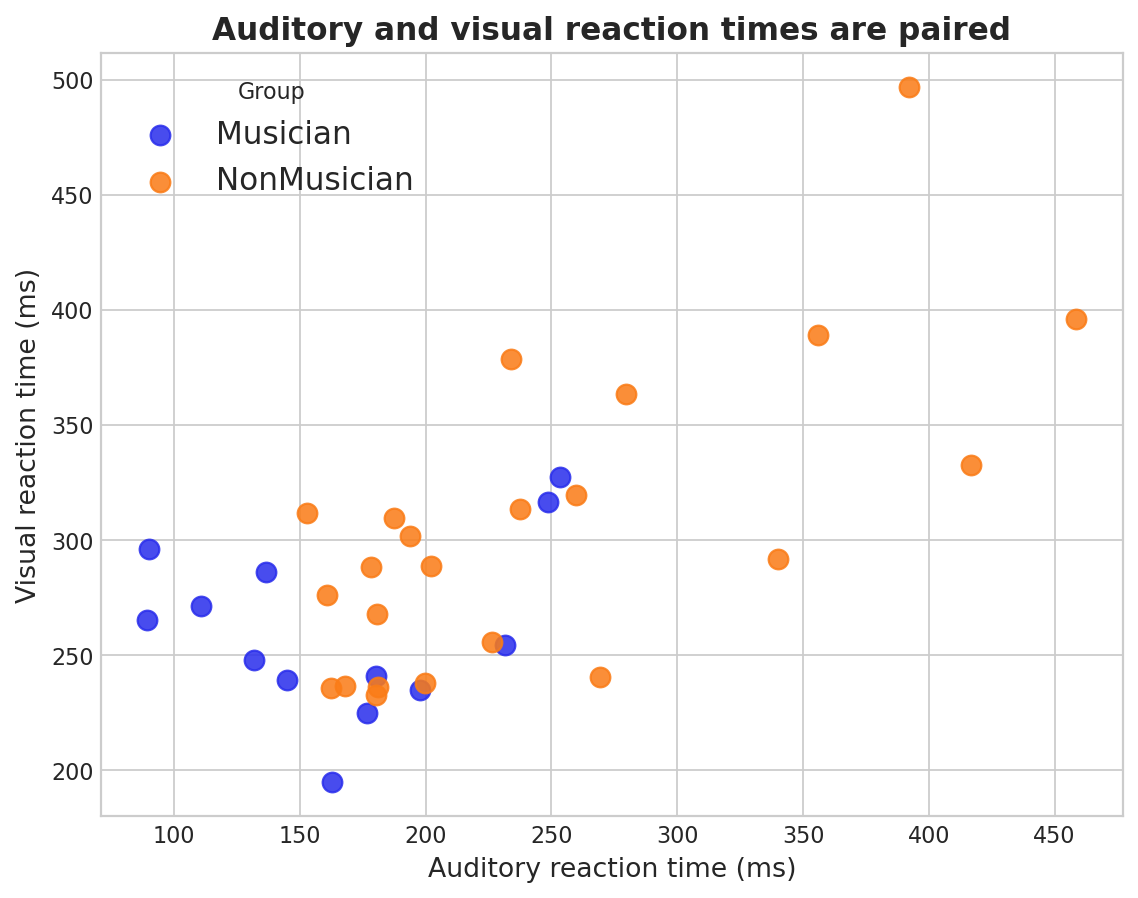

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_audiovisual_bivariate.png')

In [87]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for group_name, group_frame in audiovisual_wide.groupby("Group", observed=True):
    ax.scatter(
        group_frame["auditory"],
        group_frame["visual"],
        s=78,
        alpha=0.86,
        label=group_name,
    )

style_axis(
    ax,
    "Auditory and visual reaction times are paired",
    "Auditory reaction time (ms)",
    "Visual reaction time (ms)",
)
ax.legend(title="Group")
fig_path = save_figure(fig, "fig_audiovisual_bivariate.png")
plt.show()
fig_path

### Correlation as an effect size

Before fitting a model, it helps to understand what correlation measures and how to interpret it.

**Population correlation ρ and sample correlation r**

- ρ is the true population correlation — a parameter to be estimated.
- r (Pearson's r) is the sample estimate of ρ; under bivariate normality it is the maximum-likelihood estimate.
- ρ ∈ (−1, 1): the sign gives direction; the magnitude gives the strength of linear association.
- ρ = 0 means no linear association; |ρ| = 1 means a perfect linear relationship.

**ρ² as an effect size**

ρ² is the proportion of variance shared between the two variables. Cohen's rough thresholds for r² (not r): small ≈ 0.01, medium ≈ 0.09, large ≈ 0.25. These are conventions, not scientific definitions.

**ρ is standardized but its practical meaning is context-dependent**

ρ is dimensionless and bounded, making it comparable across studies. But its practical meaning depends strongly on context:

- Correlations vary substantially across fields — a ρ of 0.3 might be large in one domain and negligible in another.
- Correlation estimates are sensitive to measurement noise and range restriction. A noisy instrument attenuates the observed correlation toward zero; restricting the range of one variable does the same.
- The same ρ can imply very different scientific importance depending on what is being measured and what decisions depend on it.

**ROPE for correlations: field-dependent thresholds**

A Region of Practical Equivalence (ROPE) around ρ = 0 defines the range of correlations too small to be practically meaningful. There is no single universal ROPE for correlations. Illustrative examples (not universal rules):

- *Noisy behavioral data*: typical correlations are modest; |ρ| < 0.05 or |ρ| < 0.10 might be practically negligible.
- *Clinical or biological settings*: depends on intervention cost, measurement quality, and outcome severity; the threshold might be as small as |ρ| < 0.05 for a high-stakes decision, or as large as |ρ| < 0.20 for a low-stakes screening tool.
- *High-precision physical or engineering settings*: where measurements are highly reliable, even |ρ| < 0.05 may be practically important.
- *Social/behavioral science*: modest correlations (|ρ| ≈ 0.20–0.30) can be substantively meaningful for complex behavioral outcomes.

In this lecture, for the AudioVisual data we use ROPE = (−0.10, 0.10), reflecting a standardized behavioral measurement context where correlations below that level are unlikely to matter scientifically. This is an example choice, not a universal standard.

When we view the posterior for ρ:
- Posterior mass inside the ROPE → evidence of practical equivalence to zero.
- Posterior HDI entirely outside the ROPE → evidence of a practically meaningful association.

In [88]:
# Calculate Pearson r and r² for the entire sample and by group
correlation_results = []

# Overall correlation
overall_r, overall_p = stats.pearsonr(audiovisual_wide["auditory"], audiovisual_wide["visual"])
correlation_results.append({
    "group": "All participants",
    "n": len(audiovisual_wide),
    "pearson_r": overall_r,
    "r_squared": overall_r**2,
})

# By group
for group_name in group_order:
    group_data = audiovisual_wide[audiovisual_wide["Group"] == group_name]
    group_r, group_p = stats.pearsonr(group_data["auditory"], group_data["visual"])
    correlation_results.append({
        "group": group_name,
        "n": len(group_data),
        "pearson_r": group_r,
        "r_squared": group_r**2,
    })

correlation_summary = pd.DataFrame(correlation_results)
correlation_summary.round(3)

,group,n,pearson_r,r_squared
0,All participants,36,0.672,0.451
1,NonMusician,23,0.696,0.485
2,Musician,13,0.211,0.044


### Where does ρ enter a likelihood?

We want to estimate ρ using Bayesian inference. For that, ρ must appear inside a likelihood function. Standard one-dimensional likelihoods — Normal, Student-t, and so on — describe a single outcome per observation. They have no place for a correlation between two outcomes.

To model ρ, we need a likelihood that describes a *pair* of outcomes jointly. Each participant contributes one observation vector — not a single number but a (auditory RT, visual RT) pair. The likelihood must assign probability to both outcomes simultaneously.

The **bivariate normal distribution** provides exactly this. It is our first *multivariate* likelihood: one observation is a vector, not a scalar.

$$\begin{pmatrix} y_{\text{aud},i} \\ y_{\text{vis},i} \end{pmatrix} \sim \operatorname{MVNormal}(\boldsymbol{\mu},\, \Sigma)$$

The covariance matrix Σ encodes the variances of both variables and their co-variation through ρ:

$$\Sigma = \begin{pmatrix} \sigma_{\text{aud}}^2 & \rho\,\sigma_{\text{aud}}\,\sigma_{\text{vis}} \\ \rho\,\sigma_{\text{aud}}\,\sigma_{\text{vis}} & \sigma_{\text{vis}}^2 \end{pmatrix}$$

The off-diagonal entry ρ σ_aud σ_vis is how ρ enters the model. When ρ = 0, Σ is diagonal and the two outcomes are independent; when |ρ| = 1, the outcomes are perfectly co-linear. ρ is a model parameter with a prior and a posterior — not a statistic computed after fitting.

### Prior for ρ: a transformed Beta distribution

ρ ∈ (−1, 1). A direct Normal prior would need truncation. Instead, we map ρ to the unit interval where Beta distributions are natural:

$$\theta = \frac{\rho + 1}{2}, \qquad \theta \sim \operatorname{Beta}(1.3,\, 1.3), \qquad \rho = 2\theta - 1.$$

θ ∈ (0, 1), so the Beta distribution — already familiar from proportion problems — applies. Beta(1.3, 1.3) is broad and symmetric, centered at θ = 0.5 (ρ = 0), and avoids concentrating mass at the extremes ±1. Preliz was used to confirm this gives broad prior coverage without over-weighting extreme correlations. Back-transforming with ρ = 2θ − 1 gives a symmetric, diffuse prior over (−1, 1).

In [89]:
alpha_theta_rho_correlation = 1.3
beta_theta_rho_correlation = 1.3

mu_mu_correlation = 0.0
sigma_mu_correlation = 1.0
sigma_sigma_correlation = 1.0

<a id="section-112"></a>
## 11.2 Group-specific correlations in one model

We now build one Bayesian model with group-specific means, standard deviations, and correlations. The parameters are not pooled across groups in this teaching version; that keeps the model close to the question "what is the correlation in each group?" while still estimating both groups in one coherent model.

This directly gives a posterior for:

- `rho[Musician]`
- `rho[NonMusician]`
- `delta_rho = rho[Musician] - rho[NonMusician]`

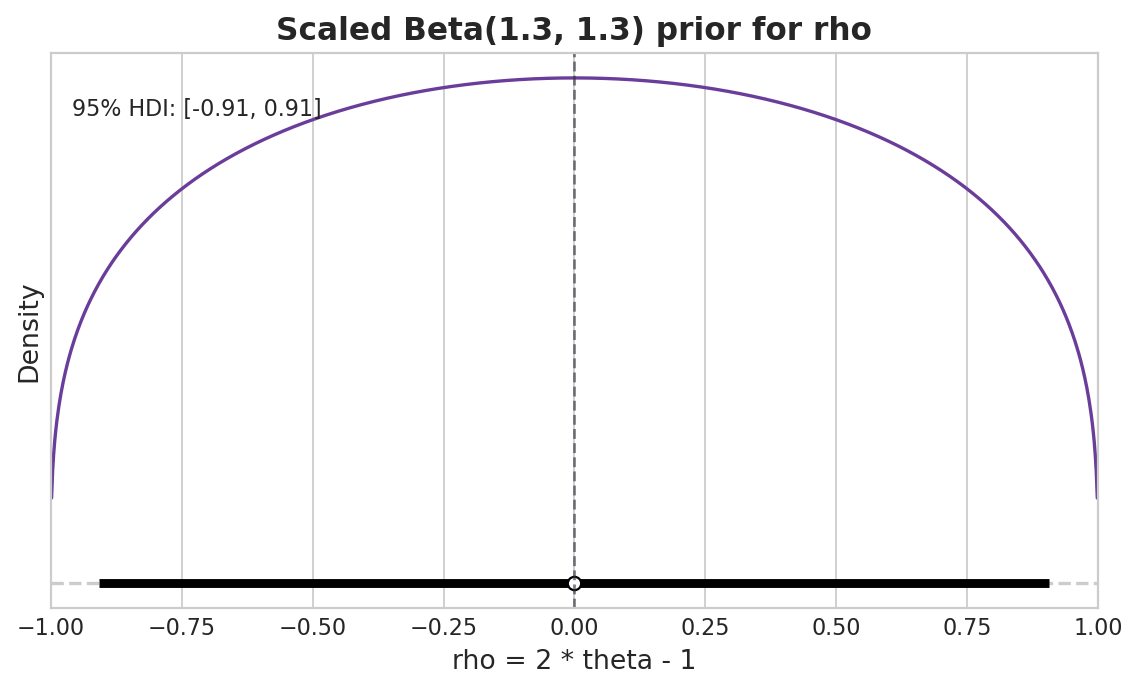

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_audiovisual_rho_prior.png')

In [90]:
rho_prior = pz.BetaScaled(
    alpha=alpha_theta_rho_correlation,
    beta=beta_theta_rho_correlation,
    lower=-1,
    upper=1,
)
rho_hdi_low, rho_hdi_high = rho_prior.hdi(0.95)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
rho_prior.plot_pdf(
    ax=ax,
    pointinterval=True,
    interval="hdi",
    levels=[0.95],
    legend="title",
    color=COLORS["reference"],
)
ax.axvline(0, color=COLORS["observed"], linestyle="--", linewidth=1.2, alpha=0.65)
style_axis(
    ax,
    "Scaled Beta(1.3, 1.3) prior for rho",
    "rho = 2 * theta - 1",
    "Density",
)
ax.set_xlim(-1, 1)
ax.text(
    0.02,
    0.92,
    f"95% HDI: [{rho_hdi_low:.2f}, {rho_hdi_high:.2f}]",
    transform=ax.transAxes,
    ha="left",
    va="top",
)
fig_path = save_figure(fig, "fig_audiovisual_rho_prior.png")
plt.show()
fig_path

In [91]:
audiovisual = audiovisual_wide[["auditory_z", "visual_z"]].to_numpy()
group_index = audiovisual_wide["group_idx"].to_numpy()

nonmusician_index = group_order.index("NonMusician")
musician_index = group_order.index("Musician")

audiovisual_coords = {
    "subject": np.arange(len(audiovisual)),
    "group": group_order,
    "rt_var": ["auditory_z", "visual_z"],
    "rt_var_cov": ["auditory_z", "visual_z"],
}

with pm.Model(coords=audiovisual_coords) as audiovisual_group_model:
    mu = pm.Normal(
        "mu",
        mu=mu_mu_correlation,
        sigma=sigma_mu_correlation,
        dims=("group", "rt_var"),
    )
    sigma = pm.HalfNormal(
        "sigma",
        sigma=sigma_sigma_correlation,
        dims=("group", "rt_var"),
    )
    # Beta prior for correlation: theta = (rho + 1) / 2, theta ~ Beta(a, b), rho = 2*theta - 1
    theta_rho = pm.Beta(
        "theta_rho",
        alpha=alpha_theta_rho_correlation,
        beta=beta_theta_rho_correlation,
        dims="group",
    )
    rho = pm.Deterministic("rho", 2 * theta_rho - 1, dims="group")
    delta_rho = pm.Deterministic(
        "delta_rho",
        rho[musician_index] - rho[nonmusician_index],
    )

    covariance_rows = [
        pt.stack(
            [
                sigma[:, 0] ** 2,
                sigma[:, 0] * sigma[:, 1] * rho,
            ],
            axis=-1,
        ),
        pt.stack(
            [
                sigma[:, 0] * sigma[:, 1] * rho,
                sigma[:, 1] ** 2,
            ],
            axis=-1,
        ),
    ]
    cov = pm.Deterministic(
        "cov",
        pt.stack(covariance_rows, axis=-2),
        dims=("group", "rt_var", "rt_var_cov"),
    )

    pm.MvNormal(
        "response_time",
        mu=mu[group_index],
        cov=cov[group_index],
        observed=audiovisual,
        dims=("subject", "rt_var"),
    )

audiovisual_group_model

           mu ~ Normal(0, 1)
        sigma ~ HalfNormal(0, 1)
    theta_rho ~ Beta(1.3, 1.3)
          rho ~ Deterministic(f(theta_rho))
    delta_rho ~ Deterministic(f(theta_rho))
          cov ~ Deterministic(f(sigma, theta_rho))
response_time ~ MultivariateNormal(f(mu, sigma, theta_rho), f(sigma, theta_rho))

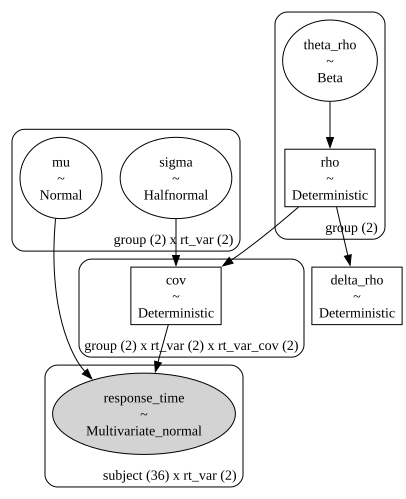

In [92]:
pm.model_to_graphviz(audiovisual_group_model)

In [93]:
with audiovisual_group_model:
    audiovisual_prior = pm.sample_prior_predictive(
        draws=PRIOR_DRAWS,
        random_seed=RANDOM_SEED,
    )
    audiovisual_idata = pm.sample(
        draws=POSTERIOR_DRAWS,
        tune=TUNE_DRAWS,
        chains=CHAINS,
        random_seed=RANDOM_SEED,
        target_accept=TARGET_ACCEPT,
        cores=1,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )
    audiovisual_idata.extend(audiovisual_prior)
    pm.sample_posterior_predictive(
        audiovisual_idata,
        var_names=["response_time"],
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
        progressbar=False,
    )

list(audiovisual_idata.groups())

Sampling: [mu, response_time, sigma, theta_rho]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, sigma, theta_rho]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 27 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [response_time]


['posterior',
 'posterior_predictive',
 'log_likelihood',
 'sample_stats',
 'prior',
 'prior_predictive',
 'observed_data']

In [94]:
diagnostic_table(audiovisual_idata, ["mu", "sigma", "rho", "delta_rho"])

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
"mu[NonMusician, auditory_z]",0.307,0.204,-0.082,0.678,513.0,410.0,1.00
"mu[NonMusician, visual_z]",0.233,0.220,-0.194,0.655,485.0,481.0,1.01
"mu[Musician, auditory_z]",-0.543,0.205,-0.957,-0.164,281.0,216.0,1.01
"mu[Musician, visual_z]",-0.429,0.185,-0.818,-0.111,445.0,339.0,1.00
"sigma[NonMusician, auditory_z]",1.052,0.157,0.788,1.351,496.0,344.0,1.01
"sigma[NonMusician, visual_z]",1.117,0.171,0.838,1.439,482.0,506.0,1.01
"sigma[Musician, auditory_z]",0.725,0.171,0.444,1.054,514.0,509.0,1.01
"sigma[Musician, visual_z]",0.707,0.168,0.412,1.022,514.0,411.0,1.00
rho[NonMusician],0.628,0.133,0.383,0.853,639.0,585.0,1.00
rho[Musician],0.157,0.253,-0.277,0.634,470.0,419.0,1.00


### Prior predictive check

Before seeing the data, the bivariate prior should generate reaction-time pairs on the standardized scale that are broad but not absurd. The exported figure uses darker, larger points so the predictive clouds remain visible at slide scale.

In [95]:
fig, ax = plt.subplots(figsize=(7.0, 5.8))
prior_rt = audiovisual_idata.prior_predictive["response_time"].stack(sample=("chain", "draw"))
prior_rt = prior_rt.transpose("sample", "subject", "rt_var")
prior_specs = [
    ("NonMusician", COLORS["light"]),
    ("Musician", COLORS["contrast"]),
]

for group_name, color in prior_specs:
    subject_mask = audiovisual_wide["Group"].eq(group_name).to_numpy()
    group_prior_rt = prior_rt.isel(subject=subject_mask)
    for sample_idx in np.linspace(0, group_prior_rt.sizes["sample"] - 1, 18, dtype=int):
        sample_values = group_prior_rt.isel(sample=sample_idx).values
        ax.scatter(sample_values[:, 0], sample_values[:, 1], s=20, color=color, alpha=0.18)

for group_name, group_frame in audiovisual_wide.groupby("Group", observed=True):
    ax.scatter(
        group_frame["auditory_z"],
        group_frame["visual_z"],
        s=70,
        alpha=0.9,
        label=f"Observed {group_name}",
    )

style_axis(
    ax,
    "Prior predictive bivariate RT clouds",
    "Auditory RT (standardized)",
    "Visual RT (standardized)",
)
ax.legend()
fig_path = save_figure(fig, "fig_audiovisual_prior_predictive.png")
plt.close(fig)
fig_path

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_audiovisual_prior_predictive.png')

In [96]:
fig, ax = plt.subplots(figsize=(7.0, 5.8))
posterior_rt = audiovisual_idata.posterior_predictive["response_time"].stack(sample=("chain", "draw"))
posterior_rt = posterior_rt.transpose("sample", "subject", "rt_var")
posterior_specs = [
    ("NonMusician", COLORS["posterior"]),
    ("Musician", COLORS["contrast"]),
]

for group_name, color in posterior_specs:
    subject_mask = audiovisual_wide["Group"].eq(group_name).to_numpy()
    group_posterior_rt = posterior_rt.isel(subject=subject_mask)
    for sample_idx in np.linspace(0, group_posterior_rt.sizes["sample"] - 1, 28, dtype=int):
        sample_values = group_posterior_rt.isel(sample=sample_idx).values
        ax.scatter(sample_values[:, 0], sample_values[:, 1], s=18, color=color, alpha=0.13)

for group_name, group_frame in audiovisual_wide.groupby("Group", observed=True):
    ax.scatter(
        group_frame["auditory_z"],
        group_frame["visual_z"],
        s=70,
        alpha=0.92,
        label=f"Observed {group_name}",
    )

style_axis(
    ax,
    "Posterior predictive bivariate RT clouds",
    "Auditory RT (standardized)",
    "Visual RT (standardized)",
)
ax.legend()
fig_path = save_figure(fig, "fig_audiovisual_posterior_predictive.png")
plt.close(fig)
fig_path

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_audiovisual_posterior_predictive.png')

### Interpreting rho and rho squared

`rho` is the correlation parameter in the model. Squaring posterior draws gives `rho_squared`, the proportion of linear association for that group.

Because this is now a two-group model, there is no single honest overall `rho_squared` to plot unless we explicitly want a mixture over groups. Here we keep both `rho` and `rho_squared` group-specific.

In [97]:
rho_nonmusician_draws = values_from_dataarray(
    audiovisual_idata.posterior["rho"].sel(group="NonMusician")
)
rho_musician_draws = values_from_dataarray(
    audiovisual_idata.posterior["rho"].sel(group="Musician")
)
delta_rho_draws = values_from_dataarray(audiovisual_idata.posterior["delta_rho"])
rho_squared_nonmusician_draws = rho_nonmusician_draws**2
rho_squared_musician_draws = rho_musician_draws**2

rho_summary = pd.DataFrame(
    [
        {"quantity": "rho_nonmusician", **summarize_draws(rho_nonmusician_draws)},
        {"quantity": "rho_musician", **summarize_draws(rho_musician_draws)},
        {"quantity": "delta_rho", **summarize_draws(delta_rho_draws)},
        {
            "quantity": "rho_squared_nonmusician",
            **summarize_draws(rho_squared_nonmusician_draws),
        },
        {
            "quantity": "rho_squared_musician",
            **summarize_draws(rho_squared_musician_draws),
        },
    ]
)

rho_summary.round(3)

,quantity,mean,sd,hdi_3%,hdi_97%
0,rho_nonmusician,0.628,0.133,0.383,0.853
1,rho_musician,0.157,0.253,-0.277,0.634
2,delta_rho,-0.471,0.290,-0.980,0.085
3,rho_squared_nonmusician,0.412,0.157,0.116,0.685
4,rho_squared_musician,0.088,0.107,0.000,0.287


C:\Users\User\AppData\Local\Temp\ipykernel_28960\2026398541.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.94])


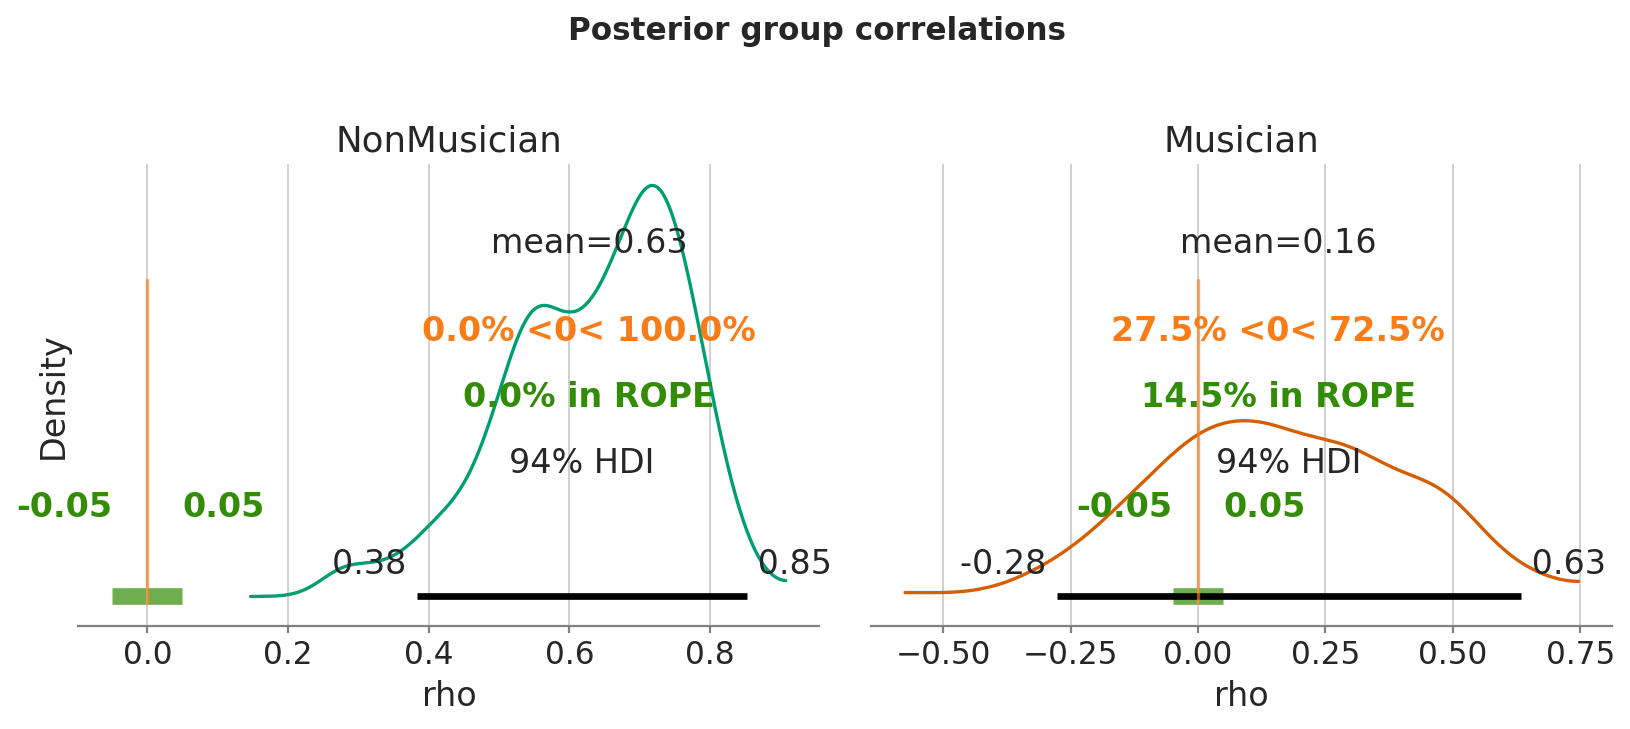

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_rho_posterior.png')

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6), sharey=True)

for ax, group_name, draws, color in [
    (axes[0], "NonMusician", rho_nonmusician_draws, COLORS["posterior"]),
    (axes[1], "Musician", rho_musician_draws, COLORS["contrast"]),
]:
    az.plot_posterior(
        {f"rho_{group_name.lower()}": draws},
        ref_val=0,
        hdi_prob=0.94,
        ax=ax,
        rope=(-0.05, 0.05),
        color=color,
    )
    ax.set_title(group_name)
    ax.set_xlabel("rho")

axes[0].set_ylabel("Density")
fig.suptitle("Posterior group correlations", fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig_path = save_figure(fig, "fig_rho_posterior.png")
plt.show()
fig_path

C:\Users\User\AppData\Local\Temp\ipykernel_28960\2549020163.py:28: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.94])


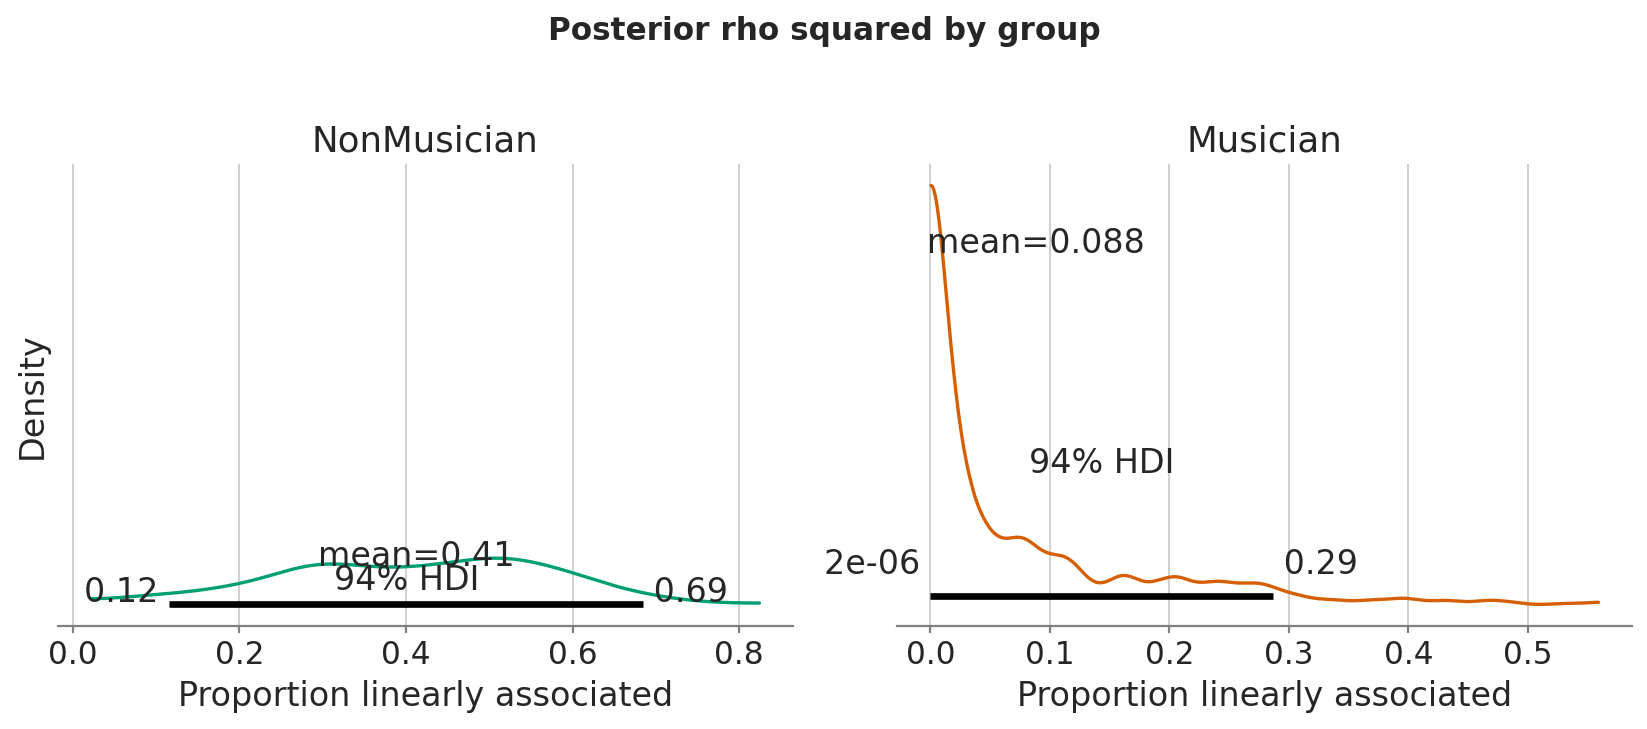

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_rho_squared_by_group.png')

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.6), sharey=True)

for ax, group_name, draws, color in [
    (
        axes[0],
        "NonMusician",
        rho_squared_nonmusician_draws,
        COLORS["posterior"],
    ),
    (
        axes[1],
        "Musician",
        rho_squared_musician_draws,
        COLORS["contrast"],
    ),
]:
    az.plot_posterior(
        {f"rho_squared_{group_name.lower()}": draws},
        hdi_prob=0.94,
        ax=ax,
        color=color,
    )
    ax.set_title(group_name)
    ax.set_xlabel("Proportion linearly associated")

axes[0].set_ylabel("Density")
fig.suptitle("Posterior rho squared by group", fontsize=14, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig_path = save_figure(fig, "fig_rho_squared_by_group.png")
plt.show()
fig_path

The Musician group is smaller (`n = 13`) than the NonMusician group (`n = 23`). That smaller sample size should show up as wider posterior uncertainty for the Musician correlation, even before we discuss any substantive group difference.

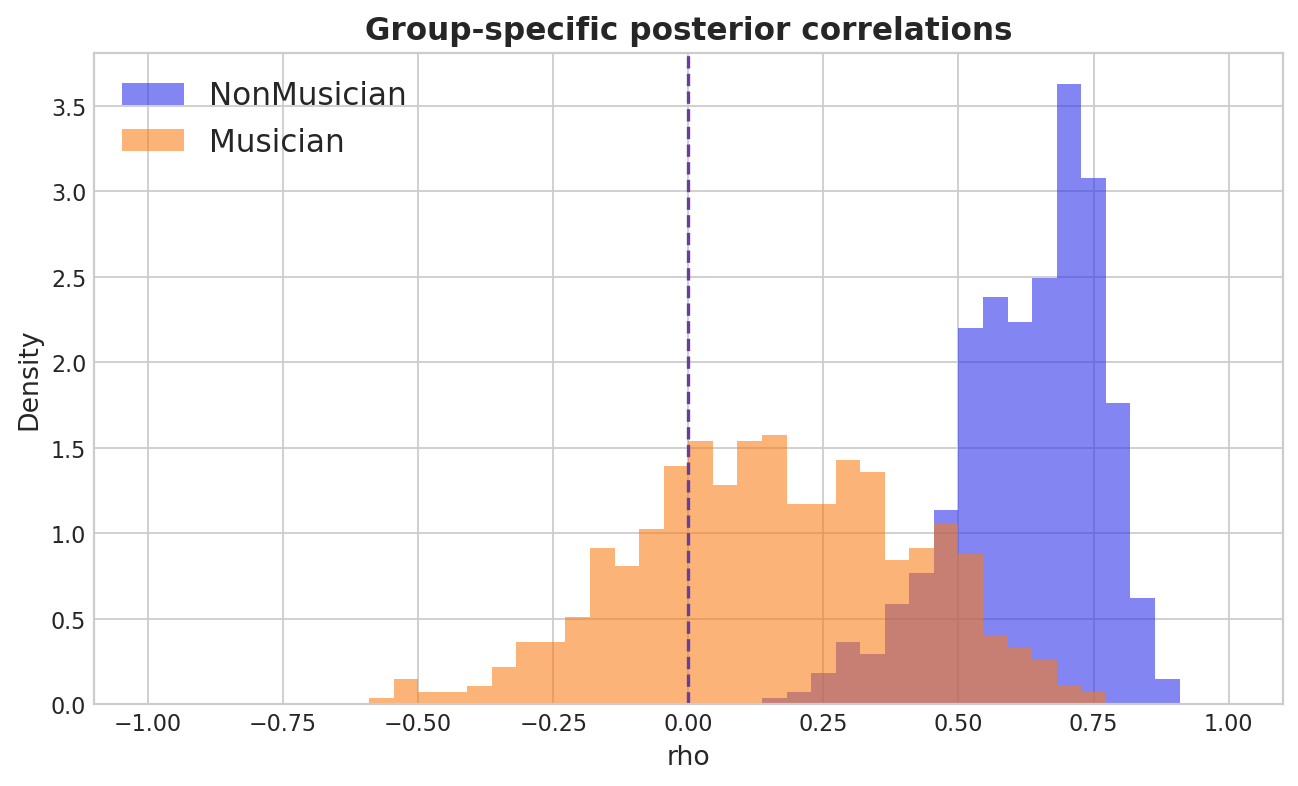

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_group_correlations.png')

In [100]:
fig, ax = plt.subplots(figsize=(8, 4.8))
bins = np.linspace(-1, 1, 45)
ax.hist(rho_nonmusician_draws, bins=bins, alpha=0.58, density=True, label="NonMusician")
ax.hist(rho_musician_draws, bins=bins, alpha=0.58, density=True, label="Musician")
ax.axvline(0, color=COLORS["reference"], lw=1.5, ls="--")
style_axis(ax, "Group-specific posterior correlations", "rho", "Density")
ax.legend()
fig_path = save_figure(fig, "fig_group_correlations.png")
plt.show()
fig_path

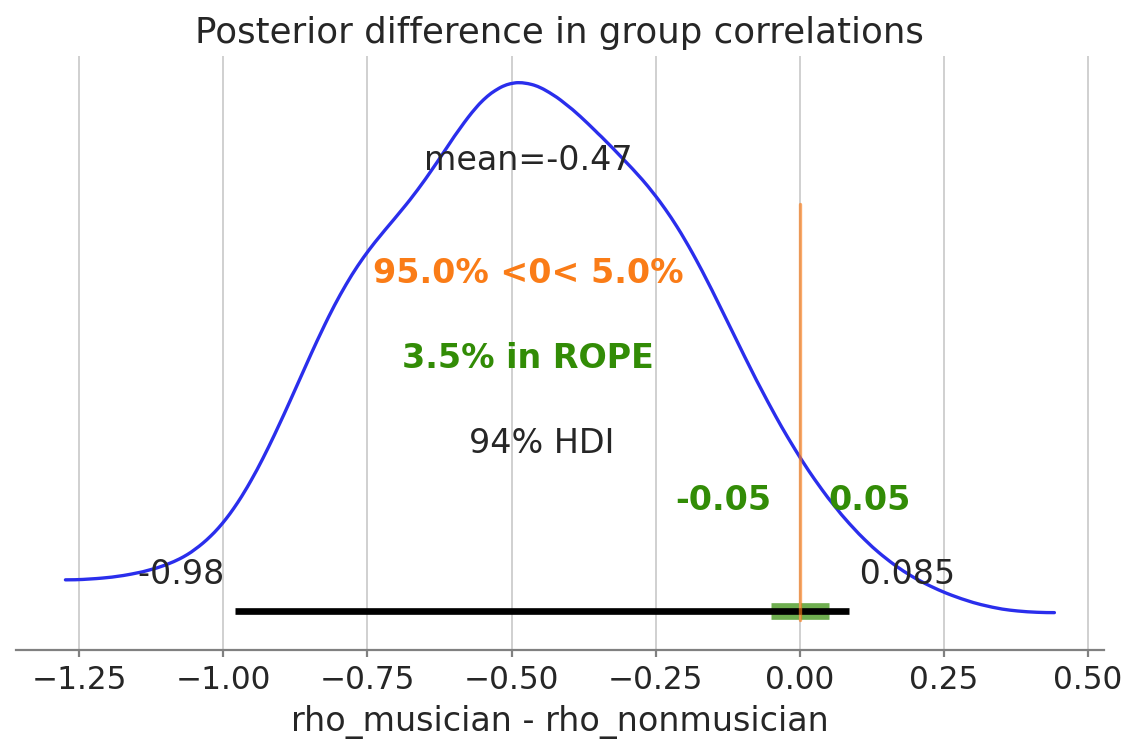

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_group_correlation_difference.png')

In [101]:
fig, ax = plt.subplots(figsize=(7, 4.6))
az.plot_posterior({"delta_rho": delta_rho_draws}, ref_val=0, 
                  hdi_prob=0.94, rope=(-0.05, 0.05), ax=ax)
ax.set_title("Posterior difference in group correlations")
ax.set_xlabel("rho_musician - rho_nonmusician")
fig_path = save_figure(fig, "fig_group_correlation_difference.png")
plt.show()
fig_path

<a id="section-113"></a>
## 11.3 Frequentist translation for correlation

Pearson's `r` is the maximum-likelihood estimate of `rho` under a bivariate normal model. For each group, `r` and a Fisher-z confidence interval give a compact frequentist summary.

**Comparing two independent correlations (Fisher-z difference test)**

To test whether the correlations in two independent groups are significantly different:

1. Transform each group's correlation: z_g = arctanh(r_g)
2. Compute the test statistic:
   $$Z = \frac{z_1 - z_2}{\sqrt{\dfrac{1}{n_1 - 3} + \dfrac{1}{n_2 - 3}}}$$
3. Under H₀: ρ₁ = ρ₂, Z follows approximately Normal(0, 1)

A confidence interval for (ρ₁ − ρ₂) can also be constructed on the z scale and back-transformed.

The Bayesian posterior for Δρ directly answers the same question, without a separate test step.

In [102]:
def pearson_ci(x, y, confidence=0.95):
    pearson_r, p_value = stats.pearsonr(x, y)
    n = len(x)
    fisher_z = np.arctanh(pearson_r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - (1 - confidence) / 2)
    lower, upper = np.tanh([fisher_z - z_crit * se, fisher_z + z_crit * se])
    return pearson_r, p_value, lower, upper


pearson_rows = []
for label, frame in [("All participants", audiovisual_wide), *audiovisual_wide.groupby("Group", observed=True)]:
    pearson_r, p_value, lower, upper = pearson_ci(frame["auditory"], frame["visual"])
    pearson_rows.append(
        {
            "sample": label,
            "n": len(frame),
            "pearson_r": pearson_r,
            "ci_2.5%": lower,
            "ci_97.5%": upper,
            "p_value_H0_rho_0": p_value,
        }
    )

pearson_table = pd.DataFrame(pearson_rows)
pearson_table.round(3)

,sample,n,pearson_r,ci_2.5%,ci_97.5%,p_value_H0_rho_0
0,All participants,36,0.672,0.441,0.819,0.00
1,Musician,13,0.211,-0.385,0.682,0.49
2,NonMusician,23,0.696,0.398,0.861,0.00


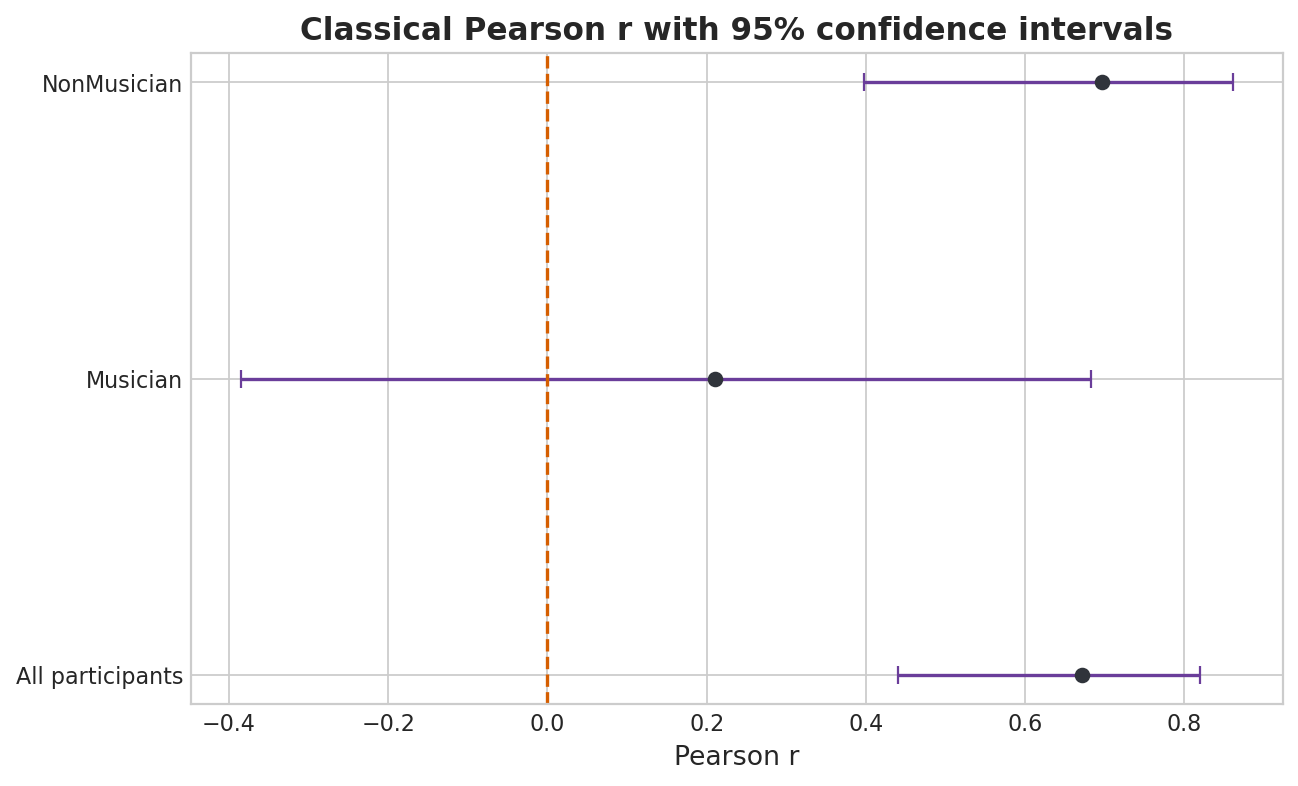

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_pearson_translation.png')

In [103]:
fig, ax = plt.subplots(figsize=(8, 4.8))
positions = np.arange(len(pearson_table))
ax.errorbar(
    pearson_table["pearson_r"],
    positions,
    xerr=[
        pearson_table["pearson_r"] - pearson_table["ci_2.5%"],
        pearson_table["ci_97.5%"] - pearson_table["pearson_r"],
    ],
    fmt="o",
    color=COLORS["observed"],
    ecolor=COLORS["reference"],
    capsize=4,
)
ax.axvline(0, color=COLORS["contrast"], lw=1.5, ls="--")
ax.set_yticks(positions)
ax.set_yticklabels(pearson_table["sample"])
style_axis(ax, "Classical Pearson r with 95% confidence intervals", "Pearson r", "")
fig_path = save_figure(fig, "fig_pearson_translation.png")
plt.show()
fig_path

### Check yourself

| Bayesian model | Pearson translation |
|---|---|
| Treats `rho` as an unknown parameter and summarizes posterior uncertainty. Can directly estimate `delta_rho` in the model. | Uses a sample statistic `r` and a sampling distribution for repeated samples. Group differences are usually handled as a secondary calculation. |

<a id="section-114"></a>
## 11.4 Repeated measurements

The Wines2012 dataset has multiple judges scoring the same wines. Scores from the same judge are dependent because they share that judge's scoring tendency. We will call this tendency **generosity**:

- positive `G_j`: more generous judge
- negative `G_j`: less generous / harsher judge
- harshness, if we use the word, is negative generosity

In [104]:
wines = pd.read_csv(WINES_PATH, sep=";")
wines["score_z"] = (wines["score"] - wines["score"].mean()) / wines["score"].std(ddof=1)

wine_order = (
    wines.groupby("wine", observed=True)["score"]
    .mean()
    .sort_values(ascending=False)
    .index
    .to_list()
)
judge_order = (
    wines.groupby("judge", observed=True)["score"]
    .mean()
    .sort_values(ascending=False)
    .index
    .to_list()
)
wines["wine_idx"] = pd.Categorical(wines["wine"], categories=wine_order, ordered=True).codes
wines["judge_idx"] = pd.Categorical(wines["judge"], categories=judge_order, ordered=True).codes

wines.head()

,judge,flight,wine,score,wine.amer,judge.amer,score_z,wine_idx,judge_idx
0,Jean-M Cardebat,white,A1,10.0,1,0,-1.576604,5,7
1,Jean-M Cardebat,white,B1,13.0,1,0,-0.450458,3,7
2,Jean-M Cardebat,white,C1,14.0,0,0,-0.075076,13,7
3,Jean-M Cardebat,white,D1,15.0,0,0,0.300306,2,7
4,Jean-M Cardebat,white,E1,8.0,1,0,-2.327368,8,7


In [105]:
wine_overview = pd.DataFrame(
    {
        "quantity": [
            "Scores",
            "Judges",
            "Wines",
            "Scores per judge",
            "Scores per wine",
        ],
        "value": [
            len(wines),
            wines["judge"].nunique(),
            wines["wine"].nunique(),
            wines.groupby("judge").size().iloc[0],
            wines.groupby("wine").size().iloc[0],
        ],
    }
)

wine_overview

,quantity,value
0,Scores,180
1,Judges,9
2,Wines,20
3,Scores per judge,20
4,Scores per wine,9


C:\Users\User\AppData\Local\Temp\ipykernel_28960\1918680481.py:19: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


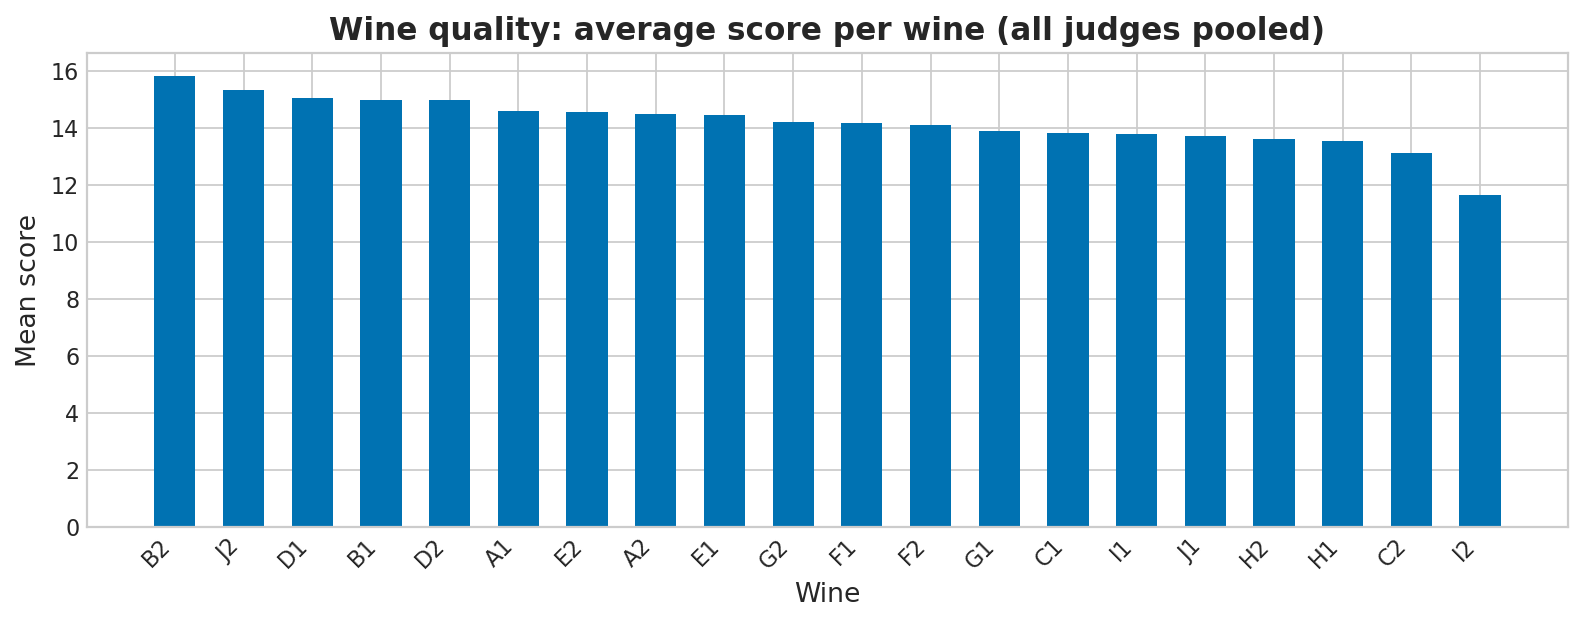

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_mean_scores.png')

In [106]:
wine_mean_scores = (
    wines.groupby("wine", observed=True)["score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"score": "mean_score"})
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    range(len(wine_mean_scores)),
    wine_mean_scores["mean_score"],
    color=COLORS["mean"],
    width=0.6,
)
ax.set_xticks(range(len(wine_mean_scores)))
ax.set_xticklabels(wine_mean_scores["wine"], rotation=45, ha="right")
style_axis(ax, "Wine quality: average score per wine (all judges pooled)", "Wine", "Mean score")
fig.tight_layout()
fig_path = save_figure(fig, "fig_wine_mean_scores.png")
plt.show()
fig_path

C:\Users\User\AppData\Local\Temp\ipykernel_28960\2258702491.py:20: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


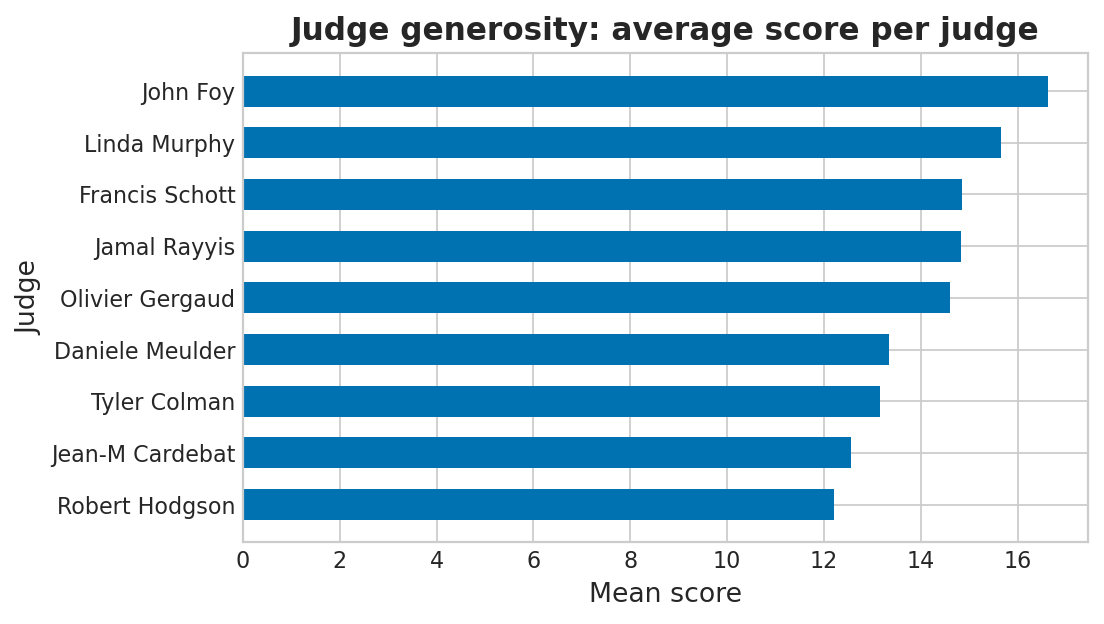

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_mean_scores.png')

In [107]:
judge_mean_scores = (
    wines.groupby("judge", observed=True)["score"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"score": "mean_score"})
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(
    range(len(judge_mean_scores)),
    judge_mean_scores["mean_score"],
    color=COLORS["mean"],
    height=0.6,
)
ax.set_yticks(range(len(judge_mean_scores)))
ax.set_yticklabels(judge_mean_scores["judge"])
ax.invert_yaxis()
style_axis(ax, "Judge generosity: average score per judge", "Mean score", "Judge")
fig.tight_layout()
fig_path = save_figure(fig, "fig_judge_mean_scores.png")
plt.show()
fig_path

### Pooled wine model: ignoring judge differences

Before building the richer model that accounts for judge generosity, we fit a simpler baseline.

The pooled model treats all ratings for the same wine as exchangeable:

$$S_{ij} = \alpha + Q_i + \varepsilon_{ij}, \qquad \sum_i Q_i = 0.$$

`Q_i` is the quality deviation for wine `i` from the grand mean `α`. No judge effects are included. The zero-sum constraint is enforced with `pm.ZeroSumNormal` so that `Q_i` values are deviations from the average wine.

This model asks: how well can we rank wines if we ignore who scored them? The heatmap below will then show whether this assumption was valid.

In [108]:
# Prior constants for pooled wine model (ignores judges)
mu_alpha_pooled = 0.0
sigma_alpha_pooled = 1.0
sigma_mu_quality_pooled = 1.0
sigma_sigma_pooled = 1.0

In [109]:
# Prepare array views and coordinate dict used across all wine models
score_z = wines["score_z"].to_numpy()
wine_idx = wines["wine_idx"].to_numpy()
judge_idx = wines["judge_idx"].to_numpy()

wine_coords = {
    "wine": wine_order,
    "judge": judge_order,
    "obs": np.arange(len(wines)),
}

with pm.Model(coords=wine_coords) as pooled_wine_model:
    alpha_pooled = pm.Normal("alpha", mu=mu_alpha_pooled, sigma=sigma_alpha_pooled)
    quality = pm.ZeroSumNormal("quality", sigma=sigma_mu_quality_pooled, dims="wine")
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_pooled)
    mu = pm.Deterministic(
        "mu",
        alpha_pooled + quality[wine_idx],
        dims="obs",
    )
    pm.Normal("score", mu=mu, sigma=sigma, observed=score_z, dims="obs")

pooled_wine_model

  alpha ~ Normal(0, 1)
quality ~ ZeroSumNormal(1, f())
  sigma ~ HalfNormal(0, 1)
     mu ~ Deterministic(f(quality, alpha))
  score ~ Normal(mu, sigma)

In [110]:
with pooled_wine_model:
    pooled_wine_idata = pm.sample(
        draws=POSTERIOR_DRAWS,
        tune=TUNE_DRAWS,
        chains=CHAINS,
        random_seed=RANDOM_SEED,
        target_accept=TARGET_ACCEPT,
        cores=1,
        progressbar=False,
    )

diagnostic_table(pooled_wine_idata, ["alpha", "quality", "sigma"])

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, quality, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
alpha,0.001,0.071,-0.149,0.117,1654.0,441.0,1.00
quality[B2],0.561,0.302,-0.032,1.083,1667.0,500.0,1.00
quality[J2],0.371,0.315,-0.204,0.971,1614.0,433.0,1.00
quality[D1],0.285,0.304,-0.232,0.878,1667.0,353.0,1.01
quality[B1],0.274,0.332,-0.300,0.938,1025.0,269.0,1.00
quality[D2],0.294,0.317,-0.273,0.913,1667.0,428.0,1.01
quality[A1],0.135,0.278,-0.386,0.638,1667.0,542.0,1.00
quality[E2],0.133,0.309,-0.438,0.735,1076.0,387.0,1.01
quality[A2],0.101,0.306,-0.546,0.591,1486.0,334.0,1.00
quality[E1],0.075,0.321,-0.510,0.619,1276.0,342.0,1.01


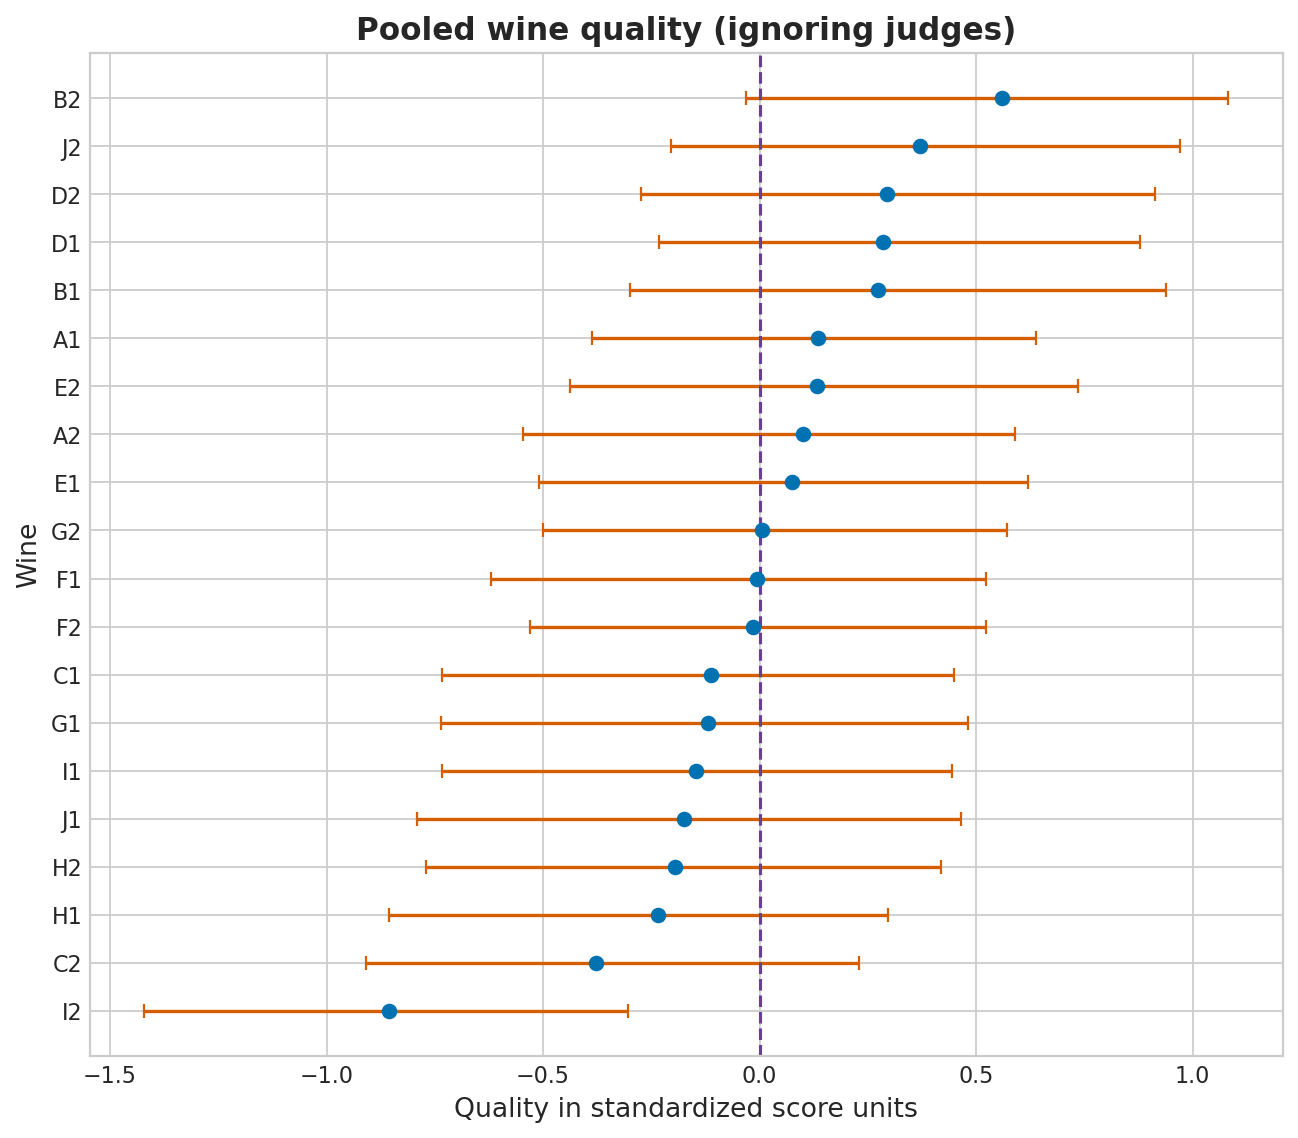

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_pooled_wine_quality.png')

In [111]:
pooled_quality_summary = az.summary(pooled_wine_idata, var_names=["quality"], hdi_prob=0.94)
pooled_quality_summary = pooled_quality_summary[["mean", "sd", "hdi_3%", "hdi_97%"]].copy()
pooled_quality_summary.index = (
    pooled_quality_summary.index
    .str.replace("quality[", "", regex=False)
    .str.replace("]", "", regex=False)
)

fig, ax = plt.subplots(figsize=(8, 7))
pq_plot = pooled_quality_summary.sort_values("mean")
positions = np.arange(len(pq_plot))
ax.errorbar(
    pq_plot["mean"],
    positions,
    xerr=[
        pq_plot["mean"] - pq_plot["hdi_3%"],
        pq_plot["hdi_97%"] - pq_plot["mean"],
    ],
    fmt="o",
    color=COLORS["mean"],
    ecolor=COLORS["contrast"],
    capsize=3,
)
ax.axvline(0, color=COLORS["reference"], lw=1.4, ls="--")
ax.set_yticks(positions)
ax.set_yticklabels(pq_plot.index)
style_axis(
    ax,
    "Pooled wine quality (ignoring judges)",
    "Quality in standardized score units",
    "Wine",
)
fig_path = save_figure(fig, "fig_pooled_wine_quality.png")
plt.show()
fig_path

C:\Users\User\AppData\Local\Temp\ipykernel_28960\2681740962.py:16: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.24, right=0.88)


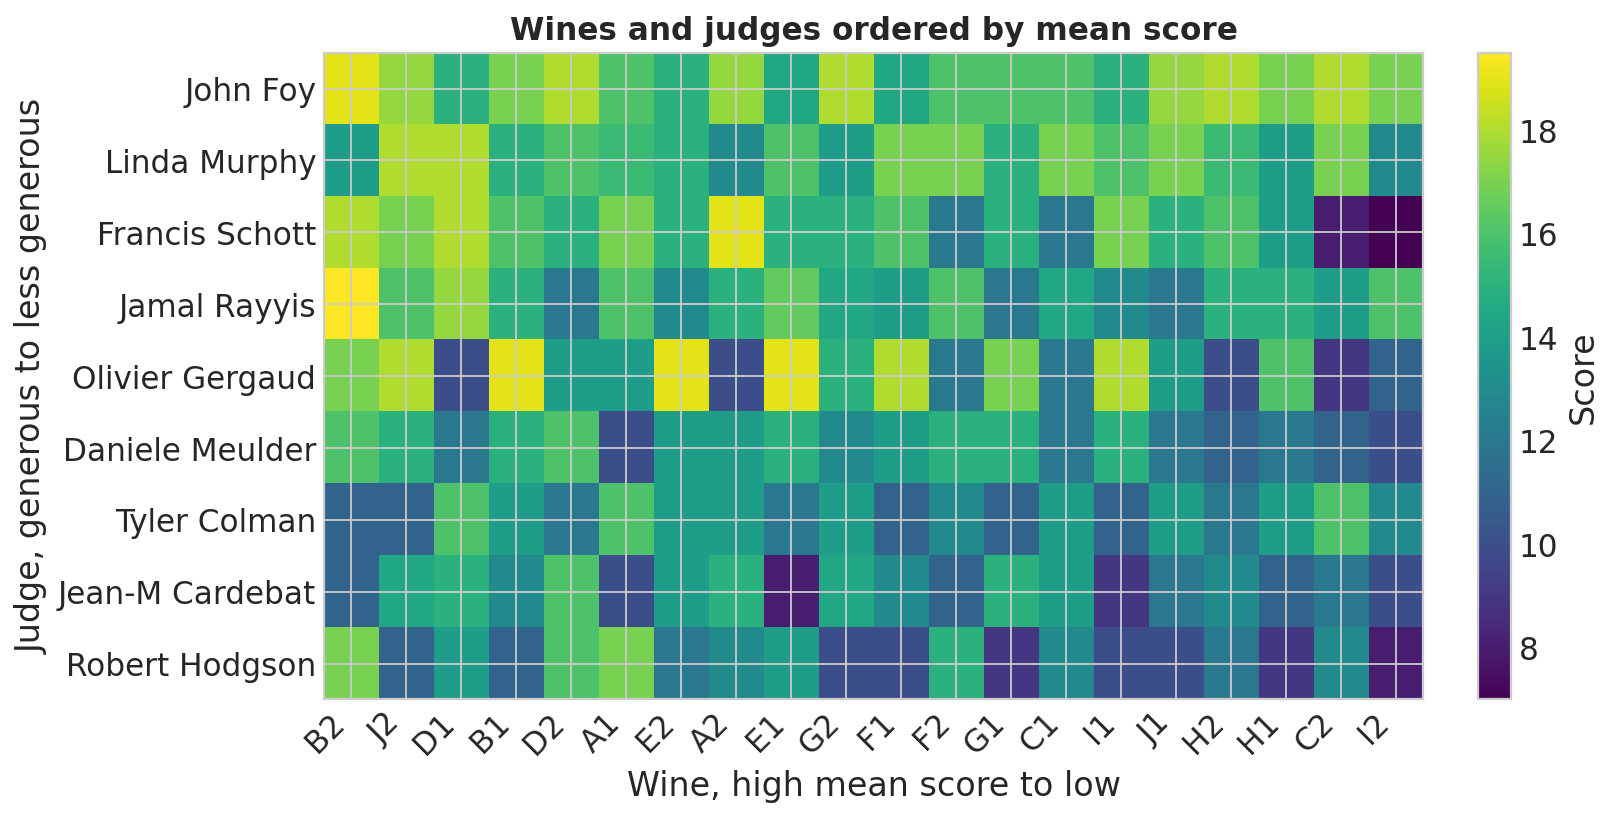

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wines_score_heatmap.png')

In [112]:
score_matrix = (
    wines.pivot_table(index="judge", columns="wine", values="score", observed=True)
    .loc[judge_order, wine_order]
)

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(score_matrix, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(wine_order)))
ax.set_xticklabels(wine_order, rotation=45, ha="right")
ax.set_yticks(np.arange(len(judge_order)))
ax.set_yticklabels(judge_order)
ax.set_title("Wines and judges ordered by mean score", fontsize=14, weight="bold")
ax.set_xlabel("Wine, high mean score to low")
ax.set_ylabel("Judge, generous to less generous")
fig.colorbar(image, ax=ax, label="Score")
fig.subplots_adjust(bottom=0.24, right=0.88)
fig_path = save_figure(fig, "fig_wines_score_heatmap.png")
plt.show()
fig_path

<a id="section-115"></a>
## 11.5 Quality, generosity, and noise

The main teaching model is

$$S_{ij} = \alpha + Q_i + G_j + \epsilon_{ij}.$$

`alpha` is the grand mean. `Q_i` is the quality of wine `i`, the inferential target — a zero-sum deviation from the grand mean enforced by `pm.ZeroSumNormal`. `G_j` is judge `j`'s generosity — also a zero-sum deviation. The score is standardized so terms can be read in score-standard-deviation units.

Judge generosity is now modeled hierarchically: all judge generosity values are drawn from Normal(0, σ_judge), where σ_judge is itself estimated from data. This is a random-effect-like structure: the inferential target is the population-level spread σ_judge, not just individual judge values.

Centering wine and judge effects makes them deviations from the grand mean. The zero-sum constraint removes the additive non-identifiability that arises when you can shift all quality values up and all generosity values down by the same constant.

In [113]:
# Grand mean
mu_alpha = 0.0
sigma_alpha = 1.0

# Wine quality (ZeroSumNormal scale)
mu_mu_quality = 0.0
sigma_mu_quality = 1.0

# Width of the hierarchical prior for judge generosity (sigma_judge)
sigma_sigma_judge = 1.0

# Residual noise
sigma_sigma_score = 1.0

# Discrimination model (bivariate normal on judge traits)
mu_mu_generosity = 0.0
sigma_mu_generosity = 1.0
mu_mu_discrimination = 0.0
sigma_mu_discrimination = 0.35
mu_rho_z_discrimination = 0.0
sigma_rho_z_discrimination = 1.0

In [114]:
# score_z, wine_idx, judge_idx, wine_coords are defined in the pooled-model cell above

with pm.Model(coords=wine_coords) as wine_repeated_model:
    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha)
    # Zero-sum wine quality effects (deviations from grand mean)
    quality = pm.ZeroSumNormal("quality", sigma=sigma_mu_quality, dims="wine")
    # Hierarchical judge generosity: sigma_judge estimated from data
    sigma_judge = pm.HalfNormal("sigma_judge", sigma=sigma_sigma_judge)
    generosity = pm.ZeroSumNormal("generosity", sigma=sigma_judge, dims="judge")
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_score)
    mu = pm.Deterministic(
        "mu",
        alpha + quality[wine_idx] + generosity[judge_idx],
        dims="obs",
    )
    pm.Normal("score", mu=mu, sigma=sigma, observed=score_z, dims="obs")

wine_repeated_model

      alpha ~ Normal(0, 1)
    quality ~ ZeroSumNormal(1, f())
sigma_judge ~ HalfNormal(0, 1)
 generosity ~ ZeroSumNormal(sigma_judge, f())
      sigma ~ HalfNormal(0, 1)
         mu ~ Deterministic(f(generosity, quality, alpha))
      score ~ Normal(mu, sigma)

In [115]:
with wine_repeated_model:
    wine_prior = pm.sample_prior_predictive(
        draws=PRIOR_DRAWS,
        random_seed=RANDOM_SEED,
    )
    wine_idata = pm.sample(
        draws=POSTERIOR_DRAWS,
        tune=TUNE_DRAWS,
        chains=CHAINS,
        random_seed=RANDOM_SEED,
        target_accept=TARGET_ACCEPT,
        cores=1,
        progressbar=False,
        idata_kwargs={"log_likelihood": True},
    )
    wine_idata.extend(wine_prior)
    pm.sample_posterior_predictive(
        wine_idata,
        random_seed=RANDOM_SEED,
        extend_inferencedata=True,
        progressbar=False,
    )

list(wine_idata.groups())

Sampling: [alpha, generosity, quality, score, sigma, sigma_judge]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [alpha, quality, sigma_judge, generosity, sigma]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sampling: [score]


['posterior',
 'posterior_predictive',
 'log_likelihood',
 'sample_stats',
 'prior',
 'prior_predictive',
 'observed_data']

In [116]:
diagnostic_table(wine_idata, ["quality", "generosity", "sigma_judge", "sigma"])

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
quality[B2],0.545,0.285,-0.060,1.005,969.0,460.0,1.00
quality[J2],0.397,0.252,-0.112,0.866,702.0,443.0,1.03
quality[D1],0.279,0.283,-0.220,0.820,734.0,508.0,1.00
quality[B1],0.280,0.277,-0.219,0.789,878.0,371.0,1.00
quality[D2],0.284,0.280,-0.215,0.821,558.0,328.0,1.01
quality[A1],0.135,0.285,-0.387,0.682,734.0,373.0,1.01
quality[E2],0.118,0.279,-0.419,0.577,976.0,521.0,1.00
quality[A2],0.094,0.263,-0.431,0.580,653.0,487.0,1.01
quality[E1],0.083,0.251,-0.399,0.514,1017.0,424.0,1.00
quality[G2],0.022,0.277,-0.517,0.491,719.0,398.0,1.00


### Prior predictive check

The prior predictive distribution is checked on the standardized score scale. It should cover plausible scores while reminding us that the model has not yet seen the judge-wine pattern.

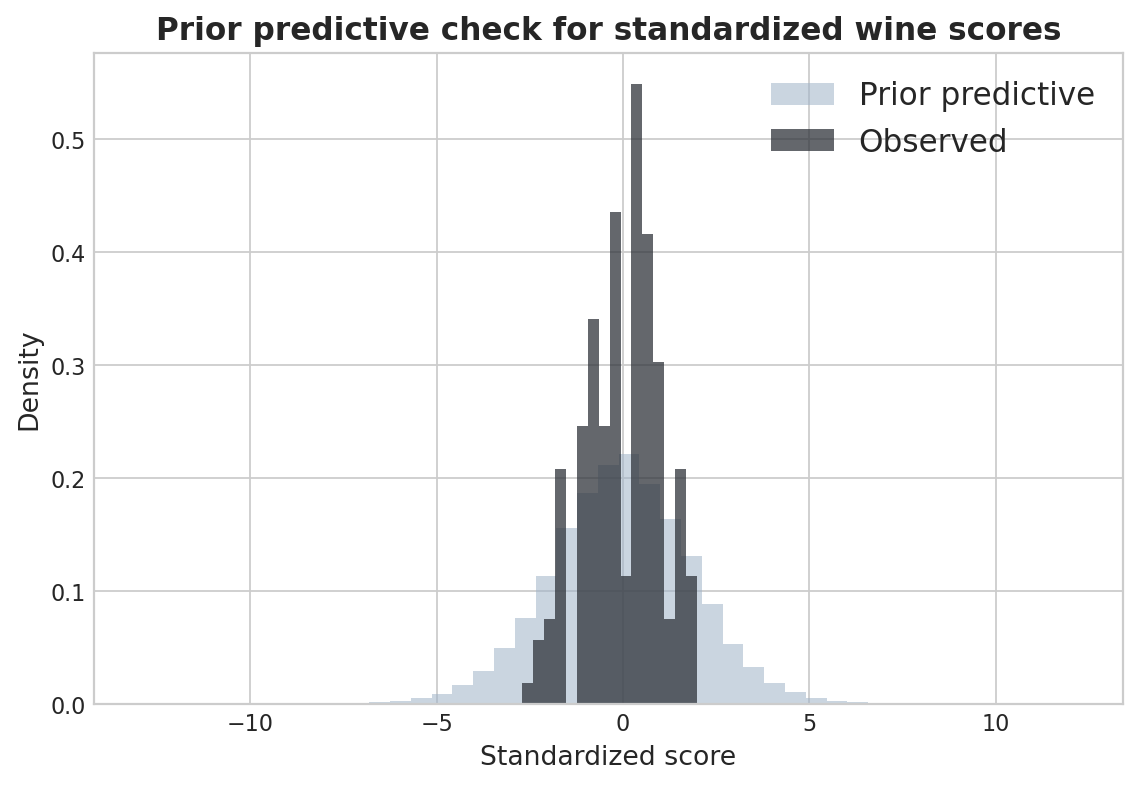

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_prior_predictive.png')

In [117]:
prior_score_draws = np.asarray(wine_idata.prior_predictive["score"]).reshape(-1)

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.hist(prior_score_draws, bins=45, density=True, alpha=0.55, color=COLORS["light"], label="Prior predictive")
ax.hist(score_z, bins=16, density=True, alpha=0.75, color=COLORS["observed"], label="Observed")
style_axis(ax, "Prior predictive check for standardized wine scores", "Standardized score", "Density")
ax.legend()
fig_path = save_figure(fig, "fig_wine_prior_predictive.png")
plt.show()
fig_path

### Wine quality

The wine quality terms are centered: positive values mean a wine tends to score above the average wine after accounting for judge generosity. Because `score_z` is standardized, a value like `0.57` means about 0.57 score standard deviations above the average wine, not 0.57 raw points on the original scale.

In [118]:
quality_summary = az.summary(wine_idata, var_names=["quality"], hdi_prob=0.94)
quality_summary = quality_summary[["mean", "sd", "hdi_3%", "hdi_97%"]].copy()
quality_summary.index = quality_summary.index.str.replace("quality[", "", regex=False).str.replace("]", "", regex=False)
quality_summary = quality_summary.sort_values("mean", ascending=False)
quality_summary.head(10).round(2)

,mean,sd,hdi_3%,hdi_97%
B2,0.55,0.28,-0.06,1.00
J2,0.40,0.25,-0.11,0.87
D2,0.28,0.28,-0.22,0.82
B1,0.28,0.28,-0.22,0.79
D1,0.28,0.28,-0.22,0.82
A1,0.14,0.28,-0.39,0.68
E2,0.12,0.28,-0.42,0.58
A2,0.09,0.26,-0.43,0.58
E1,0.08,0.25,-0.40,0.51
G2,0.02,0.28,-0.52,0.49


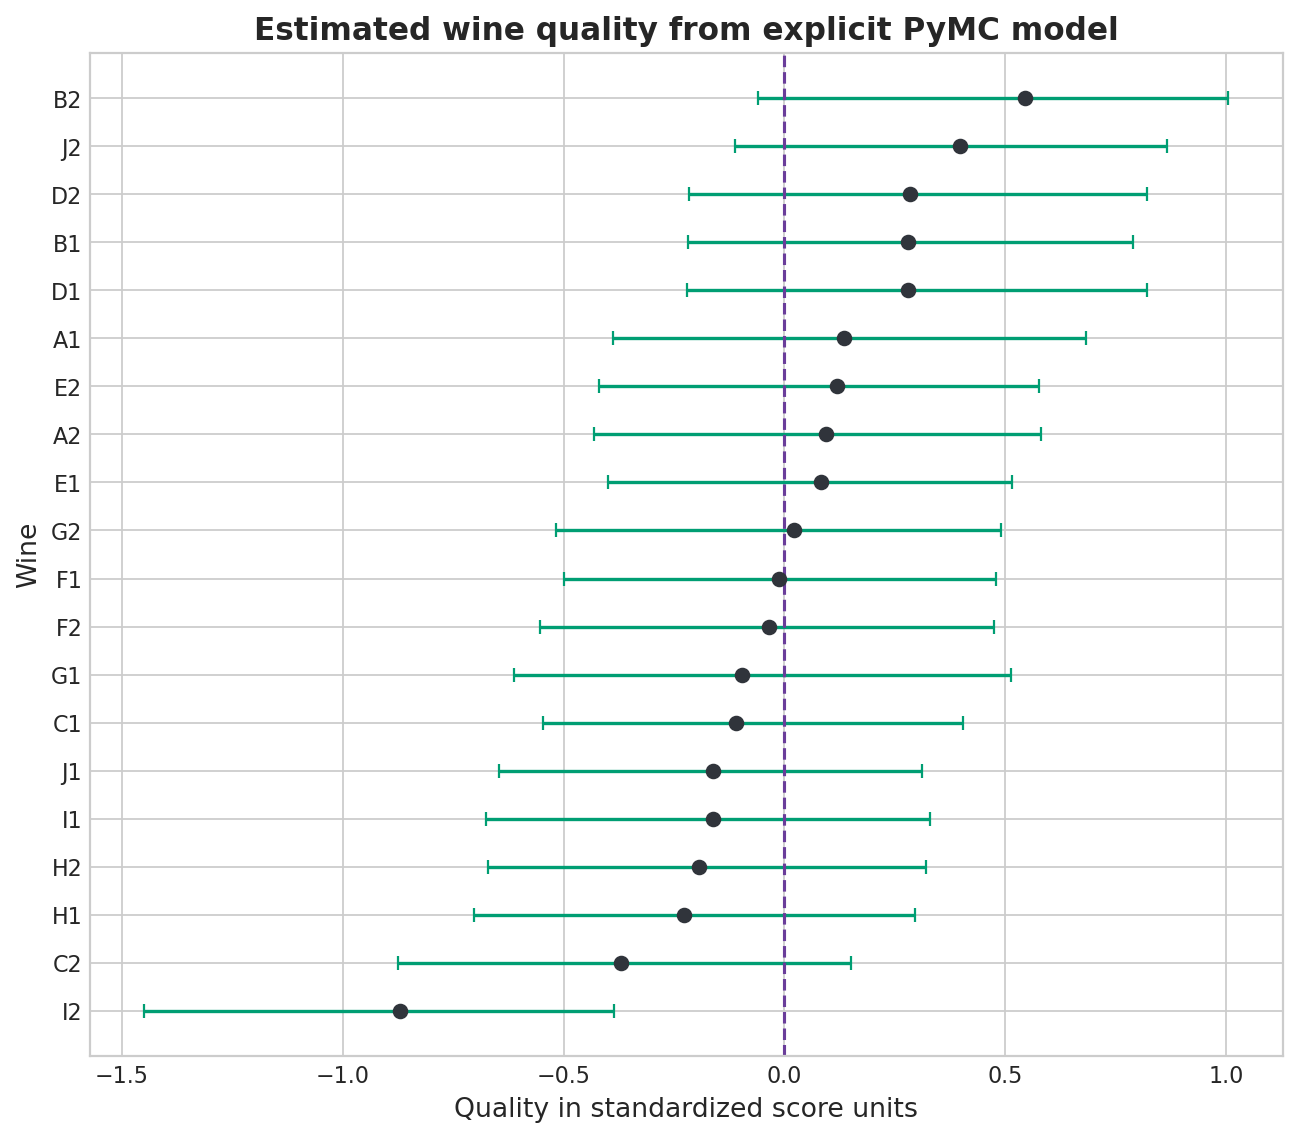

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_quality_pymc_posterior.png')

In [119]:
fig, ax = plt.subplots(figsize=(8, 7))
quality_plot = quality_summary.sort_values("mean")
positions = np.arange(len(quality_plot))
ax.errorbar(
    quality_plot["mean"],
    positions,
    xerr=[
        quality_plot["mean"] - quality_plot["hdi_3%"],
        quality_plot["hdi_97%"] - quality_plot["mean"],
    ],
    fmt="o",
    color=COLORS["observed"],
    ecolor=COLORS["posterior"],
    capsize=3,
)
ax.axvline(0, color=COLORS["reference"], lw=1.4, ls="--")
ax.set_yticks(positions)
ax.set_yticklabels(quality_plot.index)
style_axis(ax, "Estimated wine quality from explicit PyMC model", "Quality in standardized score units", "Wine")
fig_path = save_figure(fig, "fig_wine_quality_pymc_posterior.png")
plt.show()
fig_path

### Pooled versus generosity-adjusted wine quality

The pooled model and the generosity model estimate the same wine-quality target, but the pooled model ignores that each judge contributes many scores. Comparing the two sets of posterior means shows whether accounting for judge generosity changes the ranking. Comparing HDI widths shows how uncertainty changes when judge-level structure is modeled explicitly.



C:\Users\User\AppData\Local\Temp\ipykernel_28960\2893030578.py:66: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


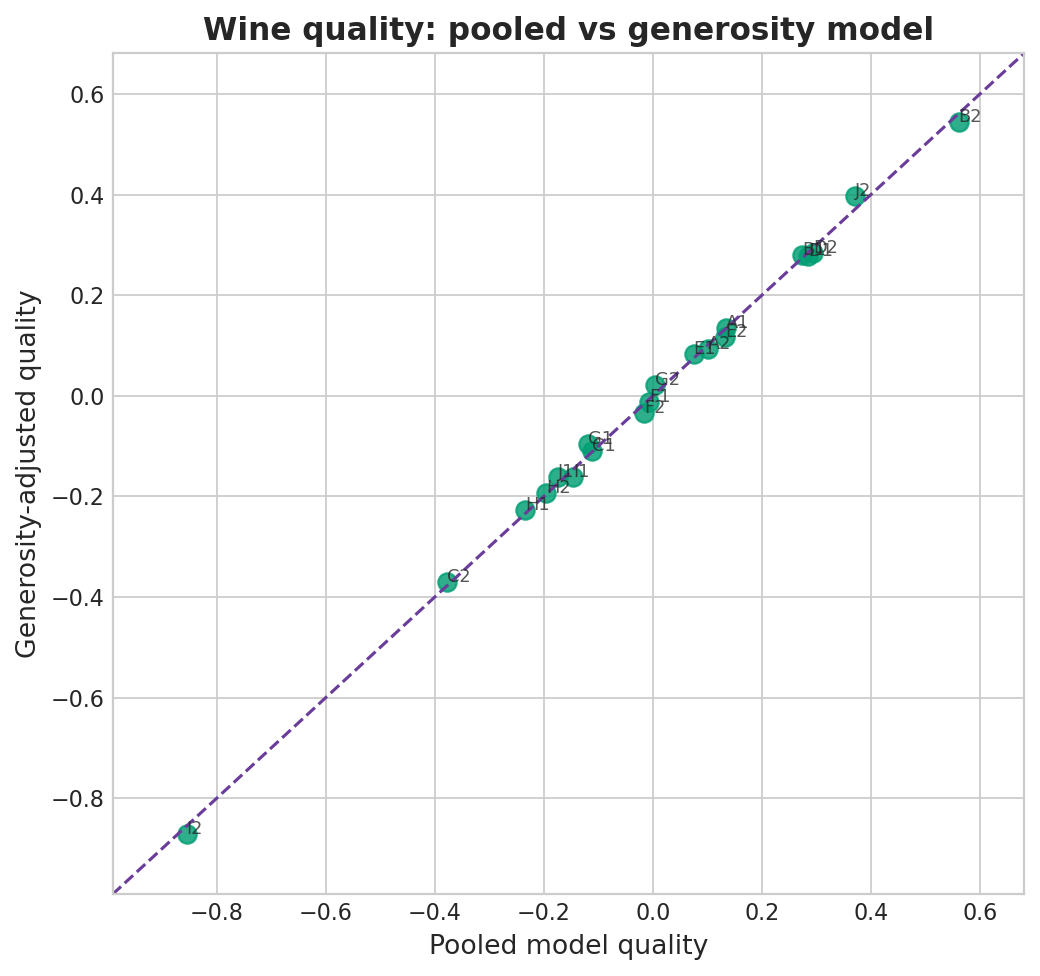

C:\Users\User\AppData\Local\Temp\ipykernel_28960\2893030578.py:100: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


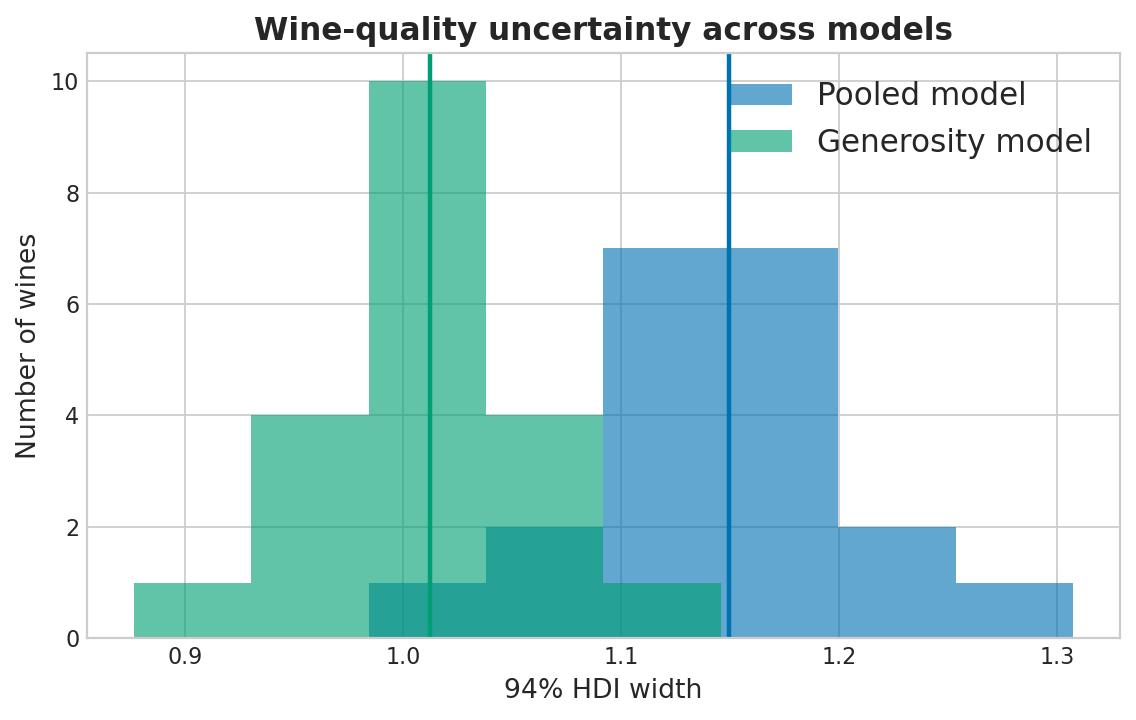

,pooled_mean,generosity_mean,pooled_hdi_width,generosity_hdi_width
B2,0.56,0.55,1.12,1.06
J2,0.37,0.40,1.18,0.98
D1,0.28,0.28,1.11,1.04
B1,0.27,0.28,1.24,1.01
D2,0.29,0.28,1.19,1.04
A1,0.14,0.14,1.02,1.07
E2,0.13,0.12,1.17,1.00
A2,0.10,0.09,1.14,1.01
E1,0.08,0.08,1.13,0.91
G2,0.00,0.02,1.07,1.01


In [120]:
quality_model_comparison = (
    pooled_quality_summary
    .rename(
        columns={
            "mean": "pooled_mean",
            "sd": "pooled_sd",
            "hdi_3%": "pooled_hdi_3%",
            "hdi_97%": "pooled_hdi_97%",
        }
    )
    [["pooled_mean", "pooled_sd", "pooled_hdi_3%", "pooled_hdi_97%"]]
    .join(
        quality_summary.rename(
            columns={
                "mean": "generosity_mean",
                "sd": "generosity_sd",
                "hdi_3%": "generosity_hdi_3%",
                "hdi_97%": "generosity_hdi_97%",
            }
        )[["generosity_mean", "generosity_sd", "generosity_hdi_3%", "generosity_hdi_97%"]]
    )
)
quality_model_comparison["pooled_hdi_width"] = (
    quality_model_comparison["pooled_hdi_97%"] - quality_model_comparison["pooled_hdi_3%"]
)
quality_model_comparison["generosity_hdi_width"] = (
    quality_model_comparison["generosity_hdi_97%"] - quality_model_comparison["generosity_hdi_3%"]
)
quality_model_comparison = quality_model_comparison.loc[wine_order]

fig, ax = plt.subplots(figsize=(6.6, 6.2))
ax.scatter(
    quality_model_comparison["pooled_mean"],
    quality_model_comparison["generosity_mean"],
    s=68,
    color=COLORS["posterior"],
    alpha=0.82,
)
for wine_label, row in quality_model_comparison.iterrows():
    ax.annotate(
        wine_label,
        (row["pooled_mean"], row["generosity_mean"]),
        fontsize=8,
        alpha=0.78,
    )

quality_limits = [
    min(
        quality_model_comparison["pooled_mean"].min(),
        quality_model_comparison["generosity_mean"].min(),
    ) - 0.12,
    max(
        quality_model_comparison["pooled_mean"].max(),
        quality_model_comparison["generosity_mean"].max(),
    ) + 0.12,
]
ax.plot(quality_limits, quality_limits, color=COLORS["reference"], ls="--", lw=1.4)
ax.set_xlim(quality_limits)
ax.set_ylim(quality_limits)
style_axis(
    ax,
    "Wine quality: pooled vs generosity model",
    "Pooled model quality",
    "Generosity-adjusted quality",
)
fig.tight_layout()
fig_path = save_figure(fig, "fig_wine_quality_pooled_vs_generosity.png")
plt.show()
fig_path

fig, ax = plt.subplots(figsize=(7.2, 4.6))
hdi_width_values = quality_model_comparison[["pooled_hdi_width", "generosity_hdi_width"]].to_numpy().ravel()
hdi_bins = np.linspace(hdi_width_values.min() * 0.96, hdi_width_values.max() * 1.04, 9)
ax.hist(
    quality_model_comparison["pooled_hdi_width"],
    bins=hdi_bins,
    alpha=0.62,
    color=COLORS["mean"],
    label="Pooled model",
)
ax.hist(
    quality_model_comparison["generosity_hdi_width"],
    bins=hdi_bins,
    alpha=0.62,
    color=COLORS["posterior"],
    label="Generosity model",
)
ax.axvline(
    quality_model_comparison["pooled_hdi_width"].mean(),
    color=COLORS["mean"],
    lw=2,
)
ax.axvline(
    quality_model_comparison["generosity_hdi_width"].mean(),
    color=COLORS["posterior"],
    lw=2,
)
style_axis(ax, "Wine-quality uncertainty across models", "94% HDI width", "Number of wines")
ax.legend()
fig.tight_layout()
fig_path = save_figure(fig, "fig_wine_quality_hdi_widths_pooled_vs_generosity.png")
plt.show()
fig_path

quality_model_comparison[
    ["pooled_mean", "generosity_mean", "pooled_hdi_width", "generosity_hdi_width"]
].round(2)



### Judge generosity

The generosity terms are also centered. Positive `G_j` means the judge tends to give higher scores than the average judge. Negative `G_j` means the judge is less generous, or harsher, than average.

In [121]:
generosity_summary = az.summary(wine_idata, var_names=["generosity"], hdi_prob=0.94)
generosity_summary = generosity_summary[["mean", "sd", "hdi_3%", "hdi_97%"]].copy()
generosity_summary.index = generosity_summary.index.str.replace("generosity[", "", regex=False).str.replace("]", "", regex=False)
generosity_summary = generosity_summary.sort_values("mean", ascending=False)
generosity_summary.round(2)

,mean,sd,hdi_3%,hdi_97%
John Foy,0.81,0.18,0.44,1.12
Linda Murphy,0.48,0.18,0.14,0.78
Francis Schott,0.23,0.18,-0.08,0.57
Jamal Rayyis,0.19,0.18,-0.16,0.52
Olivier Gergaud,0.14,0.16,-0.17,0.44
Daniele Meulder,-0.28,0.17,-0.59,0.04
Tyler Colman,-0.36,0.17,-0.67,-0.02
Jean-M Cardebat,-0.56,0.18,-0.88,-0.24
Robert Hodgson,-0.66,0.18,-1.02,-0.35


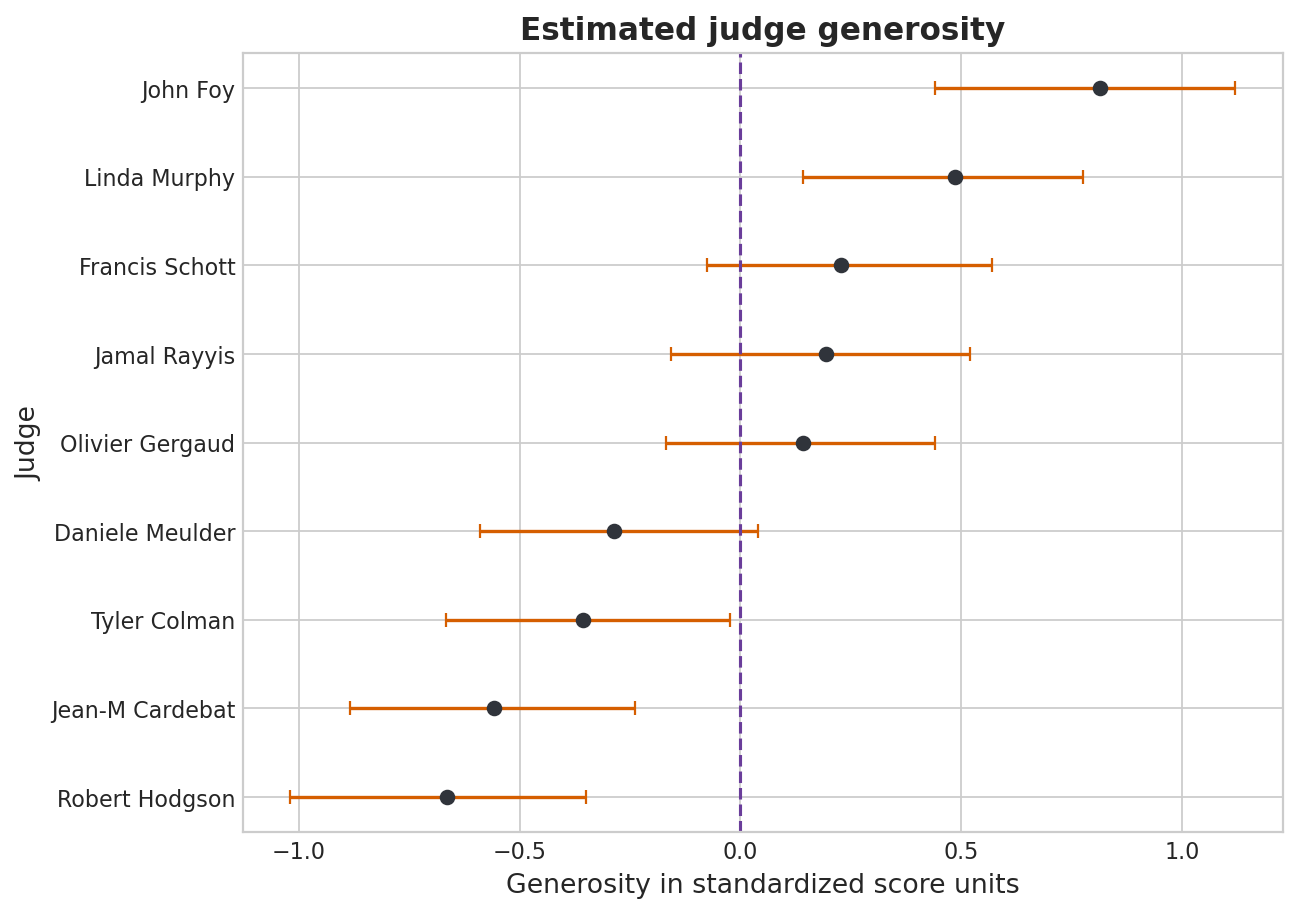

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_generosity_posterior.png')

In [122]:
fig, ax = plt.subplots(figsize=(8, 5.6))
generosity_plot = generosity_summary.sort_values("mean")
positions = np.arange(len(generosity_plot))
ax.errorbar(
    generosity_plot["mean"],
    positions,
    xerr=[
        generosity_plot["mean"] - generosity_plot["hdi_3%"],
        generosity_plot["hdi_97%"] - generosity_plot["mean"],
    ],
    fmt="o",
    color=COLORS["observed"],
    ecolor=COLORS["contrast"],
    capsize=3,
)
ax.axvline(0, color=COLORS["reference"], lw=1.4, ls="--")
ax.set_yticks(positions)
ax.set_yticklabels(generosity_plot.index)
style_axis(ax, "Estimated judge generosity", "Generosity in standardized score units", "Judge")
fig_path = save_figure(fig, "fig_judge_generosity_posterior.png")
plt.show()
fig_path

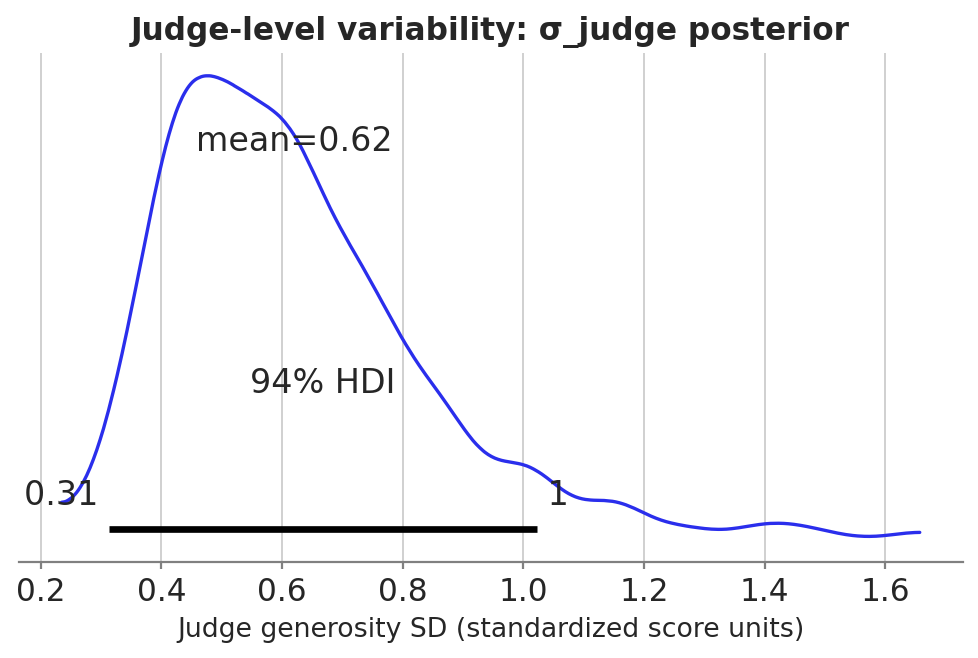

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_sigma_posterior.png')

In [123]:
fig, ax = plt.subplots(figsize=(6, 4))
az.plot_posterior(
    wine_idata,
    var_names=["sigma_judge"],
    hdi_prob=0.94,
    ax=ax,
)
ax.set_title("Judge-level variability: σ_judge posterior", fontsize=14, weight="bold")
ax.set_xlabel("Judge generosity SD (standardized score units)", fontsize=12)
fig_path = save_figure(fig, "fig_judge_sigma_posterior.png")
plt.show()
fig_path

In [124]:
fig, ax = plt.subplots(figsize=(7, 4.8))
az.plot_ppc(
    wine_idata,
    var_names=["score"],
    num_pp_samples=40,
    ax=ax,
    random_seed=RANDOM_SEED,
)
ax.set_title("Posterior predictive check: standardized wine scores")
fig_path = save_figure(fig, "fig_wine_posterior_predictive.png")
plt.close(fig)
fig_path

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_posterior_predictive.png')

<a id="section-116"></a>
## 11.6 Wilkinson/Bambi and frequentist translations

The explicit PyMC model above is written in terms of `Q_i + G_j`. In Wilkinson notation, the same statistical idea is:

```text
score_z ~ 0 + wine + (1 | judge)
```

`0 + wine` gives each wine its own fixed-effect-like estimate. `(1 | judge)` gives each judge a random-intercept-like generosity adjustment. Bambi estimates the judge-level spread, whereas the simple PyMC teaching model fixed the prior scale for generosity.


In [125]:
bambi_wine_model = bmb.Model("score_z ~ 0 + wine + (1|judge)", wines)
bambi_wine_idata = bambi_wine_model.fit(
    draws=POSTERIOR_DRAWS,
    tune=TUNE_DRAWS,
    chains=CHAINS,
    random_seed=RANDOM_SEED,
    target_accept=TARGET_ACCEPT,
    cores=1,
    progressbar=False,
)

list(bambi_wine_idata.groups())


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, wine, 1|judge_sigma, 1|judge_offset]
Sampling 2 chains for 300 tune and 300 draw iterations (600 + 600 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


['posterior', 'sample_stats', 'observed_data']

In [126]:
diagnostic_table(bambi_wine_idata, ["wine", "1|judge_sigma", "sigma"])

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
wine[A1],0.199,0.376,-0.442,0.906,160.0,367.0,1.01
wine[A2],0.150,0.357,-0.533,0.803,141.0,226.0,1.00
wine[B1],0.349,0.367,-0.302,1.014,139.0,191.0,1.00
wine[B2],0.653,0.373,-0.074,1.307,146.0,235.0,1.00
wine[C1],-0.104,0.371,-0.798,0.571,118.0,260.0,1.00
wine[C2],-0.371,0.370,-0.997,0.382,129.0,232.0,1.00
wine[D1],0.353,0.355,-0.283,0.982,128.0,195.0,1.01
wine[D2],0.350,0.368,-0.309,0.986,124.0,249.0,1.01
wine[E1],0.126,0.389,-0.536,0.905,127.0,256.0,1.00
wine[E2],0.170,0.368,-0.503,0.815,132.0,336.0,1.00


In [127]:
bambi_wine_draws = bambi_wine_idata.posterior["wine"]
bambi_wine_centered = bambi_wine_draws - bambi_wine_draws.mean(dim="wine_dim")
bambi_wine_labels = [str(label) for label in bambi_wine_centered.coords["wine_dim"].values]

bambi_quality_rows = []
for wine_label in bambi_wine_labels:
    draws = values_from_dataarray(bambi_wine_centered.sel(wine_dim=wine_label))
    bambi_quality_rows.append({"wine": wine_label, **summarize_draws(draws)})

bambi_quality_summary = (
    pd.DataFrame(bambi_quality_rows)
    .set_index("wine")
    .loc[quality_summary.index]
)

bambi_quality_summary.head().round(2)


,mean,sd,hdi_3%,hdi_97%
B2,0.61,0.28,0.07,1.11
J2,0.43,0.30,-0.15,0.94
D2,0.31,0.28,-0.22,0.82
B1,0.31,0.28,-0.19,0.86
D1,0.31,0.27,-0.21,0.83


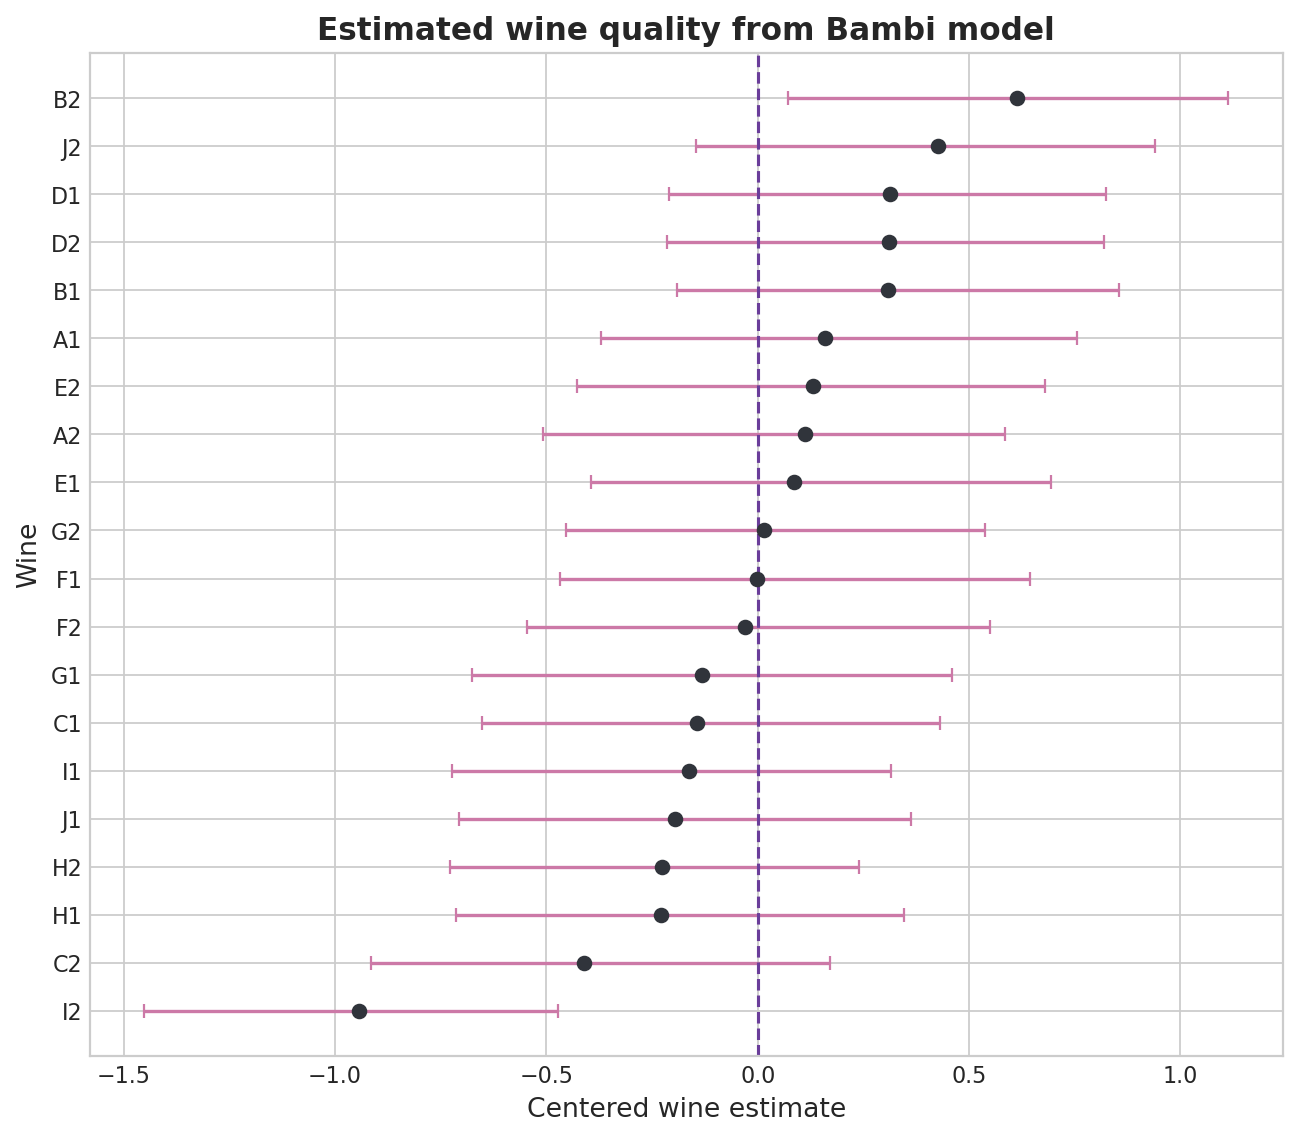

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_quality_bambi_posterior.png')

In [128]:
fig, ax = plt.subplots(figsize=(8, 7))
bambi_plot = bambi_quality_summary.sort_values("mean")
positions = np.arange(len(bambi_plot))
ax.errorbar(
    bambi_plot["mean"],
    positions,
    xerr=[
        bambi_plot["mean"] - bambi_plot["hdi_3%"],
        bambi_plot["hdi_97%"] - bambi_plot["mean"],
    ],
    fmt="o",
    color=COLORS["observed"],
    ecolor=COLORS["bambi"],
    capsize=3,
)
ax.axvline(0, color=COLORS["reference"], lw=1.4, ls="--")
ax.set_yticks(positions)
ax.set_yticklabels(bambi_plot.index)
style_axis(ax, "Estimated wine quality from Bambi model", "Centered wine estimate", "Wine")
fig_path = save_figure(fig, "fig_wine_quality_bambi_posterior.png")
plt.show()
fig_path

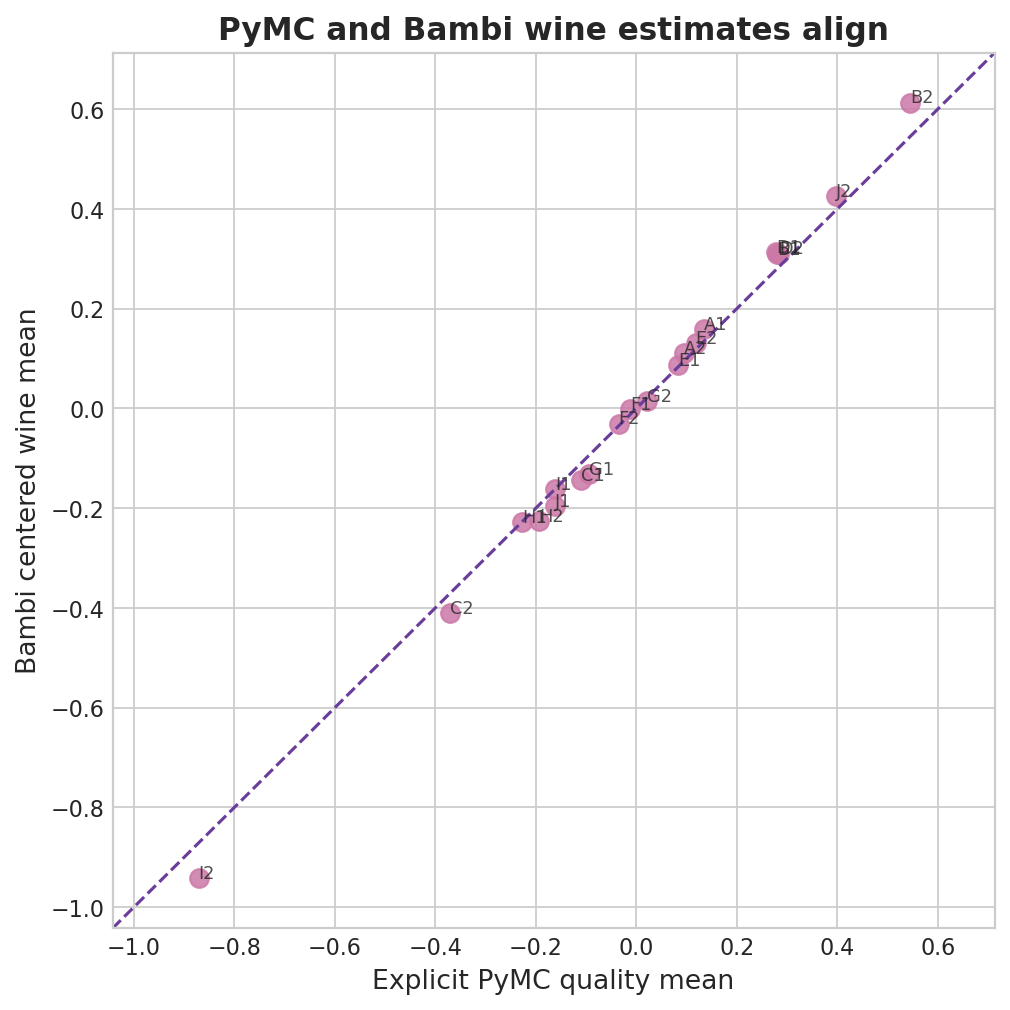

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_quality_pymc_bambi_comparison.png')

In [129]:
comparison_rows = []
for wine_label in quality_summary.index:
    comparison_rows.append(
        {
            "wine": wine_label,
            "pymc_mean": quality_summary.loc[wine_label, "mean"],
            "bambi_mean": bambi_quality_summary.loc[wine_label, "mean"],
        }
    )

quality_comparison = pd.DataFrame(comparison_rows)

fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.scatter(
    quality_comparison["pymc_mean"],
    quality_comparison["bambi_mean"],
    s=70,
    color=COLORS["bambi"],
    alpha=0.85,
)
for _, row in quality_comparison.iterrows():
    ax.annotate(row["wine"], (row["pymc_mean"], row["bambi_mean"]), fontsize=8, alpha=0.8)

lims = [
    min(quality_comparison["pymc_mean"].min(), quality_comparison["bambi_mean"].min()) - 0.1,
    max(quality_comparison["pymc_mean"].max(), quality_comparison["bambi_mean"].max()) + 0.1,
]
ax.plot(lims, lims, color=COLORS["reference"], ls="--", lw=1.4)
ax.set_xlim(lims)
ax.set_ylim(lims)
style_axis(ax, "PyMC and Bambi wine estimates align", "Explicit PyMC quality mean", "Bambi centered wine mean")
fig_path = save_figure(fig, "fig_wine_quality_pymc_bambi_comparison.png")
plt.show()
fig_path

### Frequentist translation

There are two useful frequentist translations here, and they answer slightly different teaching questions.

First, fit a fixed-effects repeated-measures approximation:

```text
score_z ~ wine + judge
```

This treats judges as blocking/fixed effects. It is useful because ordinary least squares gives the familiar whole-model F statistic and a Type-II ANOVA table with partial F tests for `wine` and `judge`.

Then fit the mixed-model analogue of the Bambi model:

```text
score_z ~ 0 + wine + (1 | judge)
```

Bambi fits that formula directly. `statsmodels` fits the same fixed/random structure with `MixedLM`: the fixed part is `score_z ~ 0 + wine`, and the random intercept is specified with `groups="judge"`.

The goal is not to build a full hypothesis-testing lecture for mixed models. Use OLS for the classical F-test mechanics, then use `MixedLM` for a compact cookbook translation of the hierarchical model.


### Fixed-effects OLS translation: classical F tests

Before the mixed model, it is useful to fit the fixed-effects repeated-measures approximation:

```text
score_z ~ wine + judge
```

This treats judges as blocking/fixed effects. It is not the final mixed model, but it gives the classical regression F test and Type-II partial-F ANOVA table directly from `statsmodels`.

In the ANOVA table, the `wine` row is the partial-F test for wine after accounting for judge, and the `judge` row is the blocking effect after accounting for wine.


In [162]:
wine_ols_formula = "score_z ~ wine + judge"
wine_ols_fit = smf.ols(wine_ols_formula, data=wines).fit()

wine_ols_overall_f = pd.DataFrame(
    [
        {
            "model": wine_ols_formula,
            "F": wine_ols_fit.fvalue,
            "df_model": wine_ols_fit.df_model,
            "df_resid": wine_ols_fit.df_resid,
            "p_value": wine_ols_fit.f_pvalue,
            "R2": wine_ols_fit.rsquared,
            "adj_R2": wine_ols_fit.rsquared_adj,
        }
    ]
)

wine_ols_anova_table = anova_lm(wine_ols_fit, typ=2).rename(
    columns={"sum_sq": "SS", "PR(>F)": "p_value"}
)
wine_ols_anova_table["MS"] = wine_ols_anova_table["SS"] / wine_ols_anova_table["df"]
wine_ols_anova_table = wine_ols_anova_table[["SS", "df", "MS", "F", "p_value"]]

display(wine_ols_overall_f.round(4))
wine_ols_anova_table.round(4)


,model,F,df_model,df_resid,p_value,R2,adj_R2
0,score_z ~ wine + judge,3.522,27.0,152.0,0.0,0.3849,0.2756


,SS,df,MS,F,p_value
wine,19.5585,19.0,1.0294,1.4210,0.1245
judge,49.3296,8.0,6.1662,8.5119,0.0000
Residual,110.1118,152.0,0.7244,NaN,NaN


### Fit one frequentist mixed model

The `MixedLM` fit below is the single frequentist model used in this section. It mirrors the Bambi formula:

```text
score_z ~ 0 + wine + (1 | judge)
```


In [160]:
wine_mixedlm_formula = "score_z ~ 0 + wine"
wine_mixedlm_fit = smf.mixedlm(
    wine_mixedlm_formula,
    data=wines,
    groups="judge",
    re_formula="1",
).fit(reml=True)

wine_mixedlm_fit.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
=======================================================
Model:            MixedLM Dependent Variable: score_z  
No. Observations: 180     Method:             REML     
No. Groups:       9       Scale:              0.7244   
Min. group size:  20      Log-Likelihood:     -231.7776
Max. group size:  20      Converged:          Yes      
Mean group size:  20.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
wine[A1]      0.154    0.333  0.464 0.643 -0.498  0.807
wine[A2]      0.113    0.333  0.338 0.735 -0.540  0.765
wine[B1]      0.300    0.333  0.902 0.367 -0.352  0.952
wine[B2]      0.613    0.333  1.843 0.065 -0.039  1.265
wine[C1]     -0.138    0.333 -0.414 0.679 -0.790  0.515
wine[C2]     -0.409    0.333 -1.228 0.219 -1.061  0.243
wine[D1]      0.321    0.333  0.965 0.334 -0.331  0.973
wine[D2]      0.300    0.333  0.902 0.367 -0.352  0.952
wine[E1]      0.092    0.333  0.276 0.783 -0.560  0.744
wine[E2]      0.133    0.333  0.401 0.688 -0.519  0.786
wine[F1]     -0.013    0.333 -0.038 0.970 -0.665  0.640
wine[F2]     -0.033    0.333 -0.100 0.920 -0.686  0.619
wine[G1]     -0.117    0.333 -0.351 0.726 -0.769  0.535
wine[G2]      0.008    0.333  0.025 0.980 -0.644  0.661
wine[H1]     -0.242    0.333 -0.727 0.467 -0.894  0.410
wine[H2]     -0.221    0.333 -0.664 0.506 -0.873  0.431
wine[I1]     -0.158    0.333 -0.476 0.634 -0.811  0.494
wine[I2]     -0.951    0.333 -2.858 0.004 -1.603 -0.299
wine[J1]     -0.179    0.333 -0.539 0.590 -0.832  0.473
wine[J2]      0.425    0.333  1.279 0.201 -0.227  1.078
judge Var     0.272    0.186                           
=======================================================

"""

### Cookbook: significance and effect size

After fitting `MixedLM`, keep the frequentist translation simple:

- Use the built-in Wald term table for a factor-level wine significance test.
- Report one wine effect size: the standard deviation of fitted wine means, in `score_z` units.

That is enough for a practical translation without turning this section into a mixed-model testing lecture.


In [161]:
wine_wald_table = wine_mixedlm_fit.wald_test_terms(scalar=True).table.copy()
wine_wald_table = wine_wald_table.rename(
    columns={"statistic": "wald_chi2", "pvalue": "p_value", "df_constraint": "df"}
)

fixed_wine_means = np.asarray(wine_mixedlm_fit.model.exog @ wine_mixedlm_fit.fe_params)
fixed_wine_sd = float(np.std(fixed_wine_means, ddof=1))

wine_effect_size = pd.DataFrame(
    [
        {
            "quantity": "fixed_wine_SD",
            "value": fixed_wine_sd,
            "interpretation": "SD of fitted wine means, in score_z units",
        }
    ]
)

display(wine_wald_table.round(4))
wine_effect_size.round(4)


,wald_chi2,p_value,df
wine,26.9989,0.1353,20


,quantity,value,interpretation
0,fixed_wine_SD,0.3306,"SD of fitted wine means, in score_z units"


In [140]:
print(wine_mixedlm_fit.model.exog.shape)
print(wine_mixedlm_fit.model.endog.shape)

(180, 20)
(180,)


In [144]:
y = wine_mixedlm_fit.model.endog
X = wine_mixedlm_fit.model.exog
Z = wine_mixedlm_fit.model.exog_re

model_sizes = {
    "n_obs": int(wine_mixedlm_fit.nobs),
    "fixed_design_shape": X.shape,
    "fixed_design_rank": int(np.linalg.matrix_rank(X)),
    "random_design_shape": None if Z is None else Z.shape,
    "n_groups": len(wine_mixedlm_fit.model.group_labels),
}

model_sizes

{'n_obs': 180,
 'fixed_design_shape': (180, 20),
 'fixed_design_rank': 20,
 'random_design_shape': (180, 1),
 'n_groups': 9}

In [146]:
import numpy as np
import pandas as pd
from scipy import stats

# Data and fixed-effect design matrix from the fitted MixedLM object
y = np.asarray(wine_mixedlm_fit.model.endog, dtype=float)
X = np.asarray(wine_mixedlm_fit.model.exog, dtype=float)

n = y.shape[0]

# Null model: grand mean only
X0 = np.ones((n, 1))

def projection_matrix(A):
    """Projection matrix onto the column space of A."""
    return A @ np.linalg.pinv(A)

# Projection matrices
P0 = projection_matrix(X0)   # intercept-only model
P1 = projection_matrix(X)    # wine fixed-effect design

# Residual-maker matrices
M0 = np.eye(n) - P0          # deviations from grand mean
M1 = np.eye(n) - P1          # residuals from wine model

# Sums of squares, computed directly as quadratic forms
SS_total = float(y @ M0 @ y)
SS_reg = float(y @ (P1 - P0) @ y)
SS_res = float(y @ M1 @ y)

# Degrees of freedom, computed directly from matrix ranks
df_total = int(np.linalg.matrix_rank(M0))
df_reg = int(np.linalg.matrix_rank(P1 - P0))
df_res = int(np.linalg.matrix_rank(M1))

# Mean squares and F statistic
MS_reg = SS_reg / df_reg
MS_res = SS_res / df_res
F_value = MS_reg / MS_res
p_value = stats.f.sf(F_value, df_reg, df_res)

anova_table = pd.DataFrame(
    {
        "source": ["wine", "residual", "total"],
        "SS": [SS_reg, SS_res, SS_total],
        "df": [df_reg, df_res, df_total],
        "MS": [MS_reg, MS_res, np.nan],
        "F": [F_value, np.nan, np.nan],
        "p": [p_value, np.nan, np.nan],
    }
)

anova_table


,source,SS,df,MS,F,p
0,wine,19.558529,19,1.029396,1.033002,0.426628
1,residual,159.441471,160,0.996509,NaN,NaN
2,total,179.000000,179,NaN,NaN,NaN


<a id="section-117"></a>
## 11.7 Custom PyMC discrimination model

The random-intercepts model says repeated scores from one judge are dependent because they share that judge's generosity, `G_j`. The final repeated-measures development lets judges differ in how strongly they separate low-quality from high-quality wines.

The model is:

$$\mu_{ij} = G_j + D_j Q_i, \qquad D_j = \exp(L_j).$$

Here `Q_i` is latent wine quality, `G_j` is judge generosity or judge-specific intercept, `L_j` is judge log-discrimination, and `D_j` is positive judge discrimination. This is random-slopes-like because judges differ in both intercept and sensitivity, but the slope is attached to a latent wine-quality scale that is inferred inside the model.

The key question is: are more generous judges also more discriminating, less discriminating, or unrelated in discrimination? To answer that, the model puts a joint distribution on `(G_j, L_j)` and estimates their correlation.

This connects the two halves of the lecture: AudioVisual modeled correlation between observed variables, while this model uses correlation between latent judge-level traits.


### Empirical motivation for discrimination

The random-intercepts model gives us estimated wine quality. We can use those estimates to ask whether some judges are more sensitive to wine quality differences than others.

**Selected judge scatter plots:** For each of a few judges, plot estimated wine quality (x) against their observed scores (y). The slope of this relationship is a rough proxy for discrimination. A steep slope means the judge separates good and bad wines clearly; a flat slope means their scores do not track the quality signal strongly.

**Discrimination proxy:** For each judge, compute the Pearson correlation between their 20 scores and the 20 estimated wine quality values. This gives a per-judge discrimination proxy — a point estimate without uncertainty. Plotting this proxy against judge generosity motivates the question of whether generous judges are also more or less discriminating.

These plots are exploratory. The full discrimination model in the next section will estimate uncertainty in both judge traits and their relationship.

C:\Users\User\AppData\Local\Temp\ipykernel_28960\3146051808.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


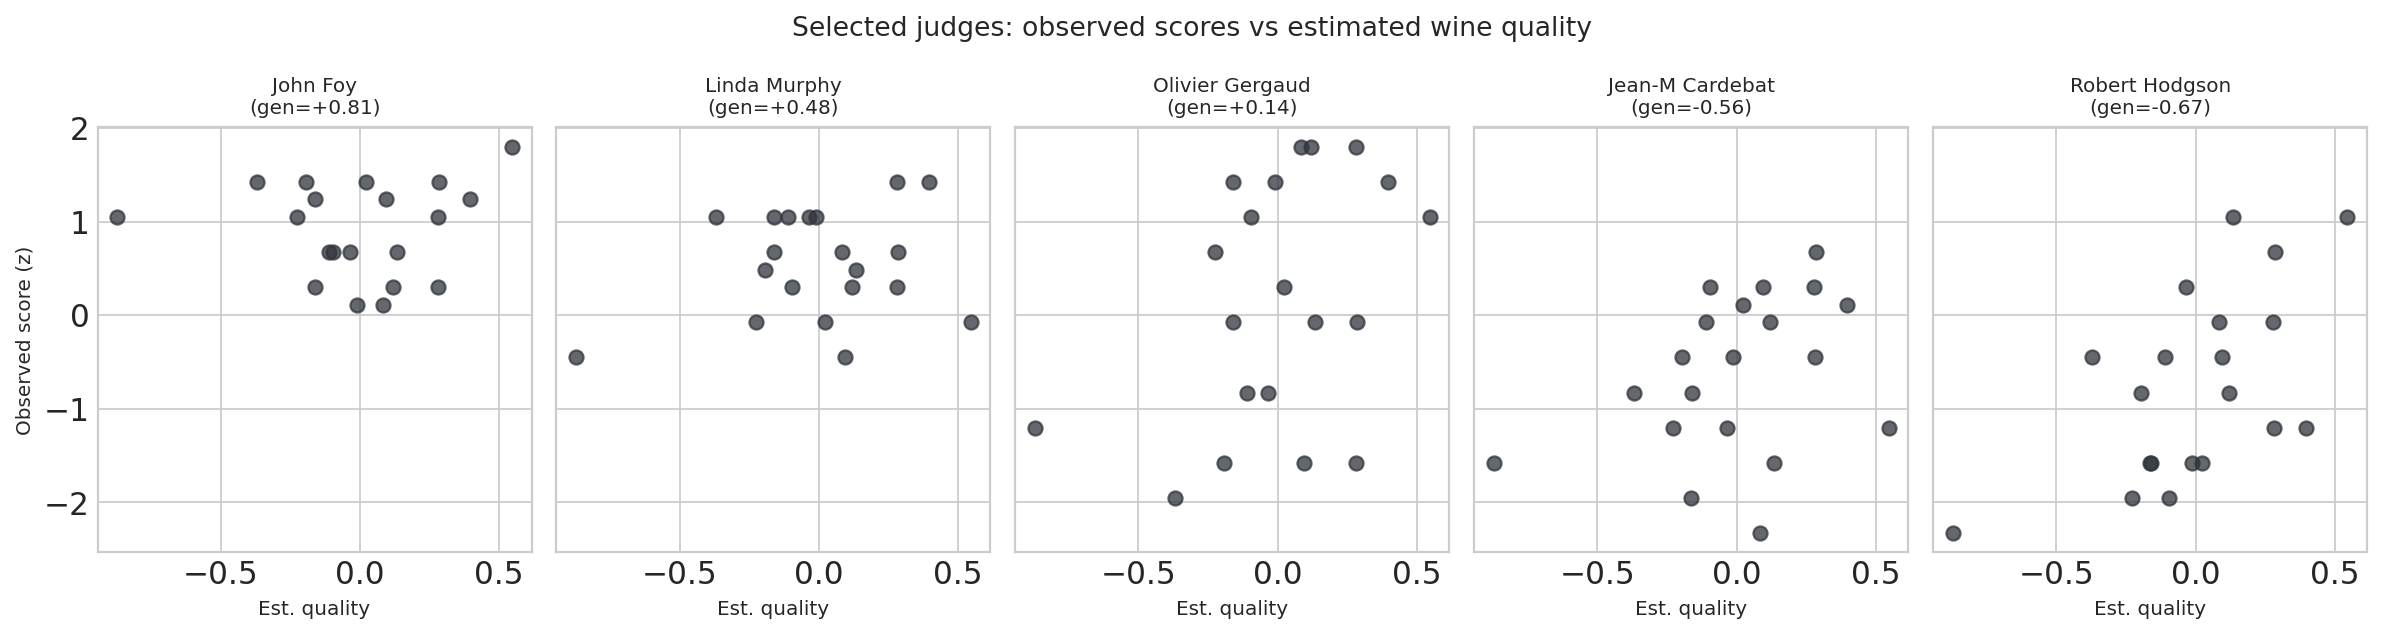

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_quality_scatter.png')

In [148]:
# Selected judges: plot estimated wine quality vs observed score
n_show = min(5, len(judge_order))
selected_judges = judge_order[:2] + [judge_order[len(judge_order) // 2]] + judge_order[-2:]
selected_judges = list(dict.fromkeys(selected_judges))[:n_show]  # unique, capped at 5

fig, axes = plt.subplots(1, len(selected_judges), figsize=(3 * len(selected_judges), 4), sharey=True)
if len(selected_judges) == 1:
    axes = [axes]

quality_means_arr = wine_idata.posterior["quality"].mean(dim=["chain", "draw"]).values
wine_quality_plot = dict(zip(wine_order, quality_means_arr))

for ax, judge_name in zip(axes, selected_judges):
    jdata = wines[wines["judge"] == judge_name]
    j_gen = float(generosity_summary.loc[judge_name, "mean"]) if judge_name in generosity_summary.index else 0.0
    j_quality = [wine_quality_plot[w] for w in jdata["wine"]]
    ax.scatter(j_quality, jdata["score_z"], alpha=0.75, color=COLORS["observed"], s=40)
    ax.set_title(f"{judge_name}\n(gen={j_gen:+.2f})", fontsize=9)
    ax.set_xlabel("Est. quality", fontsize=9)

axes[0].set_ylabel("Observed score (z)", fontsize=9)
fig.suptitle("Selected judges: observed scores vs estimated wine quality", fontsize=12)
fig.tight_layout()
fig_path = save_figure(fig, "fig_judge_quality_scatter.png")
plt.show()
fig_path

C:\Users\User\AppData\Local\Temp\ipykernel_28960\107089514.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


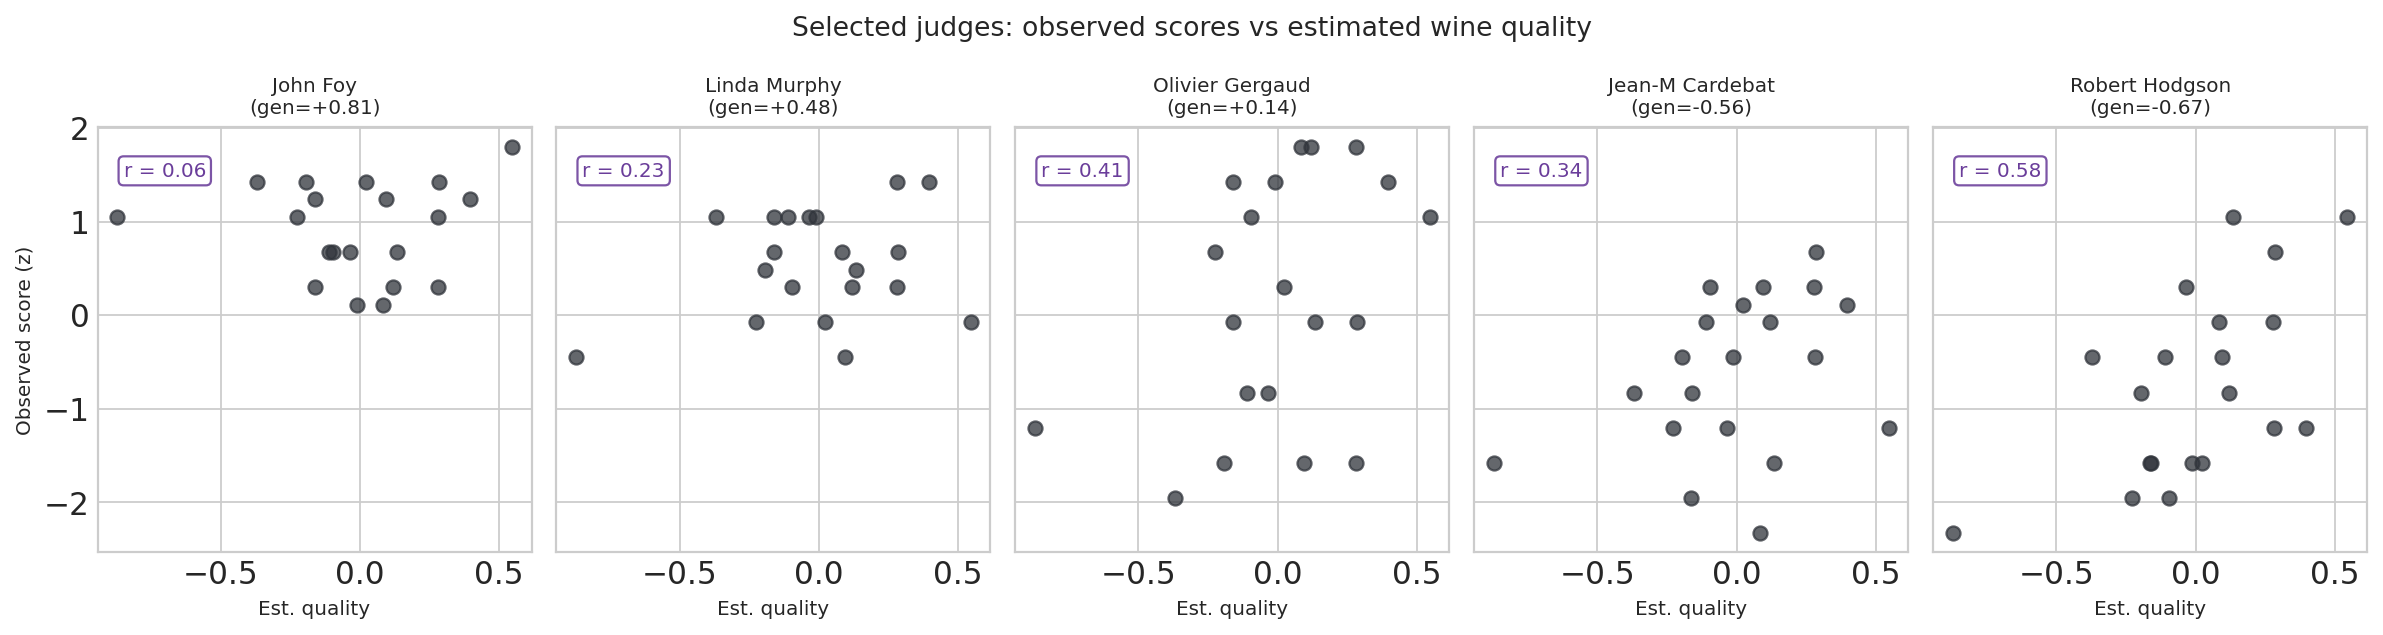

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_quality_scatter_with_correlations.png')

In [149]:
# Selected judges: plot estimated wine quality vs observed score, with sample r
fig, axes = plt.subplots(1, len(selected_judges), figsize=(3 * len(selected_judges), 4), sharey=True)
if len(selected_judges) == 1:
    axes = [axes]

for ax, judge_name in zip(axes, selected_judges):
    jdata = wines[wines["judge"] == judge_name]
    j_gen = float(generosity_summary.loc[judge_name, "mean"]) if judge_name in generosity_summary.index else 0.0
    j_quality = np.array([wine_quality_plot[w] for w in jdata["wine"]], dtype=float)
    j_scores = jdata["score_z"].to_numpy(dtype=float)
    sample_r = stats.pearsonr(j_quality, j_scores).statistic

    ax.scatter(j_quality, j_scores, alpha=0.75, color=COLORS["observed"], s=40)
    ax.text(
        0.06,
        0.92,
        f"r = {sample_r:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        color=COLORS["reference"],
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": COLORS["reference"], "alpha": 0.88},
    )
    ax.set_title(f"{judge_name}\n(gen={j_gen:+.2f})", fontsize=9)
    ax.set_xlabel("Est. quality", fontsize=9)

axes[0].set_ylabel("Observed score (z)", fontsize=9)
fig.suptitle("Selected judges: observed scores vs estimated wine quality", fontsize=12)
fig.tight_layout()
fig_path = save_figure(fig, "fig_judge_quality_scatter_with_correlations.png")
plt.show()
fig_path


C:\Users\User\AppData\Local\Temp\ipykernel_28960\2347257538.py:39: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


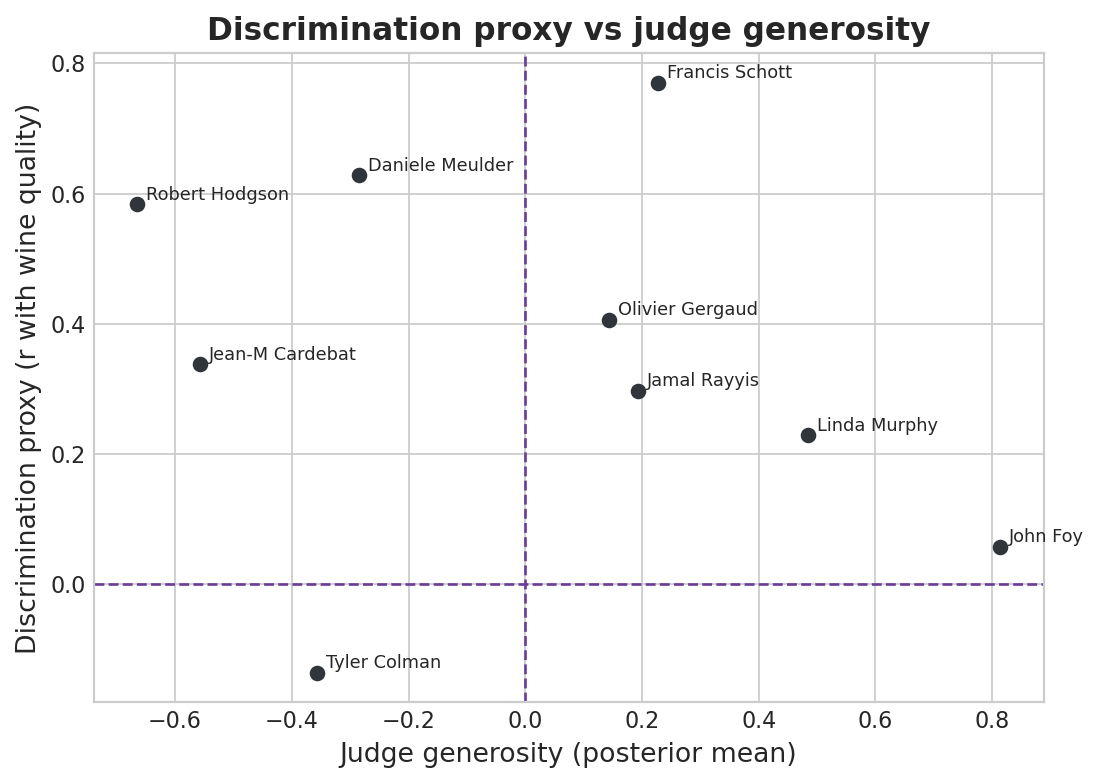

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_discrimination_proxy.png')

In [150]:
# Per-judge discrimination proxy: correlation between judge scores and estimated wine quality
quality_means_dict = dict(
    zip(
        wine_order,
        wine_idata.posterior["quality"].mean(dim=["chain", "draw"]).values,
    )
)

judge_discrim_proxy = {}
judge_gen_proxy = {}
for judge_name in judge_order:
    jdata = wines[wines["judge"] == judge_name]
    j_scores = jdata["score_z"].values
    j_quality = np.array([quality_means_dict[w] for w in jdata["wine"]])
    judge_discrim_proxy[judge_name] = float(np.corrcoef(j_quality, j_scores)[0, 1])
    judge_gen_proxy[judge_name] = float(generosity_summary.loc[judge_name, "mean"]) if judge_name in generosity_summary.index else 0.0

disc_vals = [judge_discrim_proxy[j] for j in judge_order]
gen_vals = [judge_gen_proxy[j] for j in judge_order]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(gen_vals, disc_vals, color=COLORS["observed"], zorder=3)
for j in judge_order:
    ax.annotate(
        j,
        (judge_gen_proxy[j], judge_discrim_proxy[j]),
        fontsize=8,
        xytext=(4, 2),
        textcoords="offset points",
    )
ax.axhline(0, color=COLORS["reference"], lw=1.2, ls="--")
ax.axvline(0, color=COLORS["reference"], lw=1.2, ls="--")
style_axis(
    ax,
    "Discrimination proxy vs judge generosity",
    "Judge generosity (posterior mean)",
    "Discrimination proxy (r with wine quality)",
)
fig.tight_layout()
fig_path = save_figure(fig, "fig_judge_discrimination_proxy.png")
plt.show()
fig_path

In [151]:
random_slope_coords = {
    **wine_coords,
    "judge_effect": ["generosity", "log_discrimination"],
}

with pm.Model(coords=random_slope_coords) as random_slope_discrimination_model:
    raw_quality = pm.Normal(
        "raw_quality",
        mu=mu_mu_quality,
        sigma=sigma_mu_quality,
        dims="wine",
    )
    quality = pm.Deterministic(
        "quality",
        raw_quality - pm.math.mean(raw_quality),
        dims="wine",
    )
    rho_z_generosity_discrimination = pm.Normal(
        "rho_z_generosity_discrimination",
        mu=mu_rho_z_discrimination,
        sigma=sigma_rho_z_discrimination,
    )
    rho_generosity_discrimination = pm.Deterministic(
        "rho_generosity_discrimination",
        pt.tanh(rho_z_generosity_discrimination),
    )
    judge_effect_mu = pm.math.stack([mu_mu_generosity, mu_mu_discrimination])
    judge_effect_cov = pm.math.stack(
        [
            pm.math.stack(
                [
                    sigma_mu_generosity**2,
                    sigma_mu_generosity
                    * sigma_mu_discrimination
                    * rho_generosity_discrimination,
                ]
            ),
            pm.math.stack(
                [
                    sigma_mu_generosity
                    * sigma_mu_discrimination
                    * rho_generosity_discrimination,
                    sigma_mu_discrimination**2,
                ]
            ),
        ]
    )
    raw_judge_effects = pm.MvNormal(
        "raw_judge_effects",
        mu=judge_effect_mu,
        cov=judge_effect_cov,
        dims=("judge", "judge_effect"),
    )
    raw_generosity = raw_judge_effects[:, 0]
    raw_log_discrimination = raw_judge_effects[:, 1]
    generosity = pm.Deterministic(
        "generosity",
        raw_generosity - pm.math.mean(raw_generosity),
        dims="judge",
    )
    log_discrimination = pm.Deterministic(
        "log_discrimination",
        raw_log_discrimination - pm.math.mean(raw_log_discrimination),
        dims="judge",
    )
    discrimination = pm.Deterministic(
        "discrimination",
        pm.math.exp(log_discrimination),
        dims="judge",
    )
    sigma = pm.HalfNormal("sigma", sigma=sigma_sigma_score)
    mu = pm.Deterministic(
        "mu",
        generosity[judge_idx] + discrimination[judge_idx] * quality[wine_idx],
        dims="obs",
    )
    pm.Normal("score", mu=mu, sigma=sigma, observed=score_z, dims="obs")

random_slope_discrimination_model


                    raw_quality ~ Normal(0, 1)
rho_z_generosity_discrimination ~ Normal(0, 1)
              raw_judge_effects ~ MultivariateNormal(f(rho_z_generosity_discrimination), f(rho_z_generosity_discrimination))
                          sigma ~ HalfNormal(0, 1)
                        quality ~ Deterministic(f(raw_quality))
  rho_generosity_discrimination ~ Deterministic(f(rho_z_generosity_discrimination))
                     generosity ~ Deterministic(f(raw_judge_effects))
             log_discrimination ~ Deterministic(f(raw_judge_effects))
                 discrimination ~ Deterministic(f(raw_judge_effects))
                             mu ~ Deterministic(f(raw_quality, raw_judge_effects))
                          score ~ Normal(mu, sigma)

In [152]:
with random_slope_discrimination_model:
    random_slope_discrimination_idata = pm.sample(
        draws=600,
        tune=600,
        chains=2,
        random_seed=RANDOM_SEED,
        target_accept=0.95,
        cores=1,
        progressbar=False,
    )

diagnostic_table(
    random_slope_discrimination_idata,
    [
        "rho_generosity_discrimination",
        "quality",
        "generosity",
        "log_discrimination",
        "discrimination",
        "sigma",
    ],
)


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [raw_quality, rho_z_generosity_discrimination, raw_judge_effects, sigma]
Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
rho_generosity_discrimination,-0.149,0.507,-0.992,0.682,290.0,229.0,1.00
quality[B2],0.575,0.238,0.137,1.038,1570.0,724.0,1.00
quality[J2],0.378,0.252,-0.068,0.873,1830.0,633.0,1.00
quality[D1],0.256,0.255,-0.229,0.727,1215.0,869.0,1.01
quality[B1],0.272,0.248,-0.184,0.746,1510.0,911.0,1.00
quality[D2],0.258,0.249,-0.196,0.722,1628.0,825.0,1.00
quality[A1],0.158,0.248,-0.293,0.645,1886.0,873.0,1.00
quality[E2],0.136,0.250,-0.340,0.608,1807.0,701.0,1.00
quality[A2],0.129,0.248,-0.368,0.578,1578.0,816.0,1.00
quality[E1],0.128,0.247,-0.317,0.568,1540.0,1099.0,1.00


In [153]:
random_slope_divergences = int(random_slope_discrimination_idata.sample_stats["diverging"].sum())

random_slope_quality_mean_by_draw = random_slope_discrimination_idata.posterior["quality"].mean(dim="wine")
random_slope_generosity_mean_by_draw = random_slope_discrimination_idata.posterior["generosity"].mean(dim="judge")
random_slope_log_discrimination_mean_by_draw = random_slope_discrimination_idata.posterior["log_discrimination"].mean(dim="judge")
random_slope_discrimination_min = float(random_slope_discrimination_idata.posterior["discrimination"].min())
random_slope_rho_draws = values_from_dataarray(
    random_slope_discrimination_idata.posterior["rho_generosity_discrimination"]
)

random_slope_overview = pd.DataFrame(
    [
        {
            "quantity": "rho_generosity_discrimination",
            **summarize_draws(random_slope_rho_draws),
        },
        {
            "quantity": "Pr(rho_generosity_discrimination < 0)",
            "mean": float(np.mean(random_slope_rho_draws < 0)),
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
        {
            "quantity": "Pr(rho_generosity_discrimination > 0)",
            "mean": float(np.mean(random_slope_rho_draws > 0)),
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
        {
            "quantity": "Divergences",
            "mean": float(random_slope_divergences),
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
        {
            "quantity": "Max abs mean quality per draw",
            "mean": float(np.abs(random_slope_quality_mean_by_draw).max()),
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
        {
            "quantity": "Max abs mean generosity per draw",
            "mean": float(np.abs(random_slope_generosity_mean_by_draw).max()),
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
        {
            "quantity": "Max abs mean log-discrimination per draw",
            "mean": float(np.abs(random_slope_log_discrimination_mean_by_draw).max()),
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
        {
            "quantity": "Minimum discrimination draw",
            "mean": random_slope_discrimination_min,
            "sd": np.nan,
            "hdi_3%": np.nan,
            "hdi_97%": np.nan,
        },
    ]
)

random_slope_overview.round(3)


,quantity,mean,sd,hdi_3%,hdi_97%
0,rho_generosity_discrimination,-0.149,0.507,-0.992,0.682
1,Pr(rho_generosity_discrimination < 0),0.612,NaN,NaN,NaN
2,Pr(rho_generosity_discrimination > 0),0.388,NaN,NaN,NaN
3,Divergences,0.000,NaN,NaN,NaN
4,Max abs mean quality per draw,0.000,NaN,NaN,NaN
5,Max abs mean generosity per draw,0.000,NaN,NaN,NaN
6,Max abs mean log-discrimination per draw,0.000,NaN,NaN,NaN
7,Minimum discrimination draw,0.345,NaN,NaN,NaN


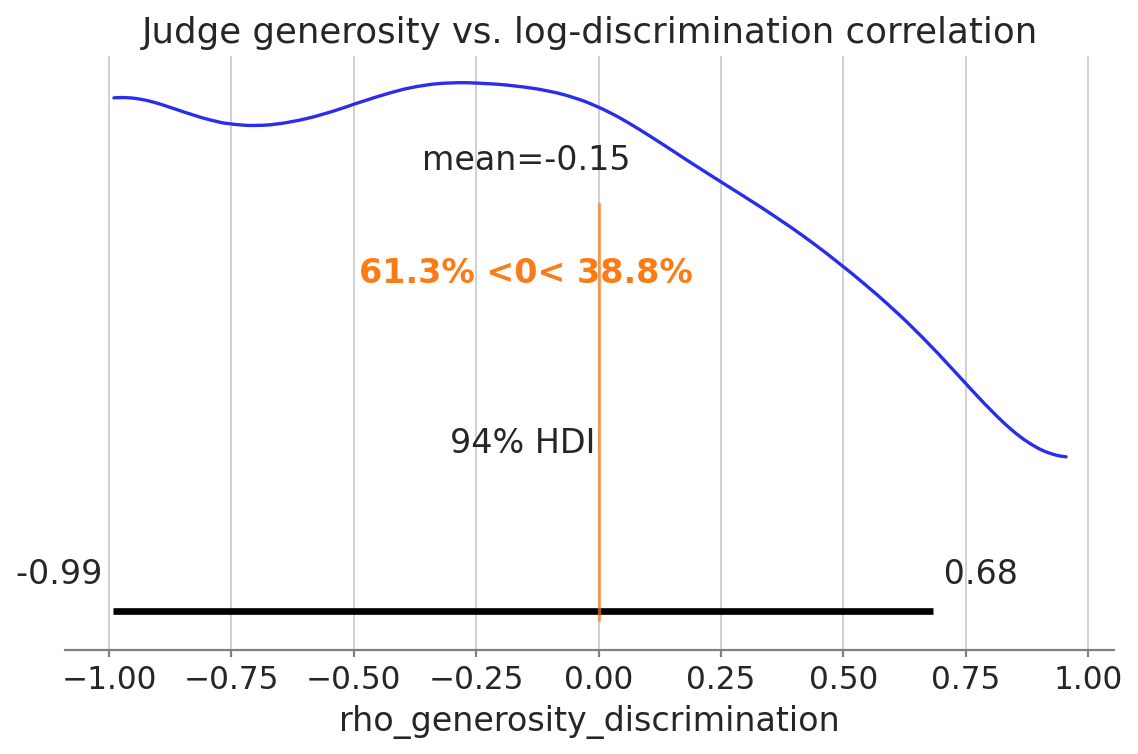

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_generosity_discrimination_correlation.png')

In [154]:
fig, ax = plt.subplots(figsize=(7, 4.6))
az.plot_posterior(
    random_slope_discrimination_idata,
    var_names=["rho_generosity_discrimination"],
    ref_val=0,
    hdi_prob=0.94,
    ax=ax,
)
ax.set_title("Judge generosity vs. log-discrimination correlation")
ax.set_xlabel("rho_generosity_discrimination")
fig_path = save_figure(fig, "fig_judge_generosity_discrimination_correlation.png")
plt.show()
fig_path


With only 9 judges, the posterior for this latent-trait correlation stays very wide. The posterior mean is slightly negative, but that is weak evidence rather than a strong finding. This is uncertainty from limited data, not a model failure.


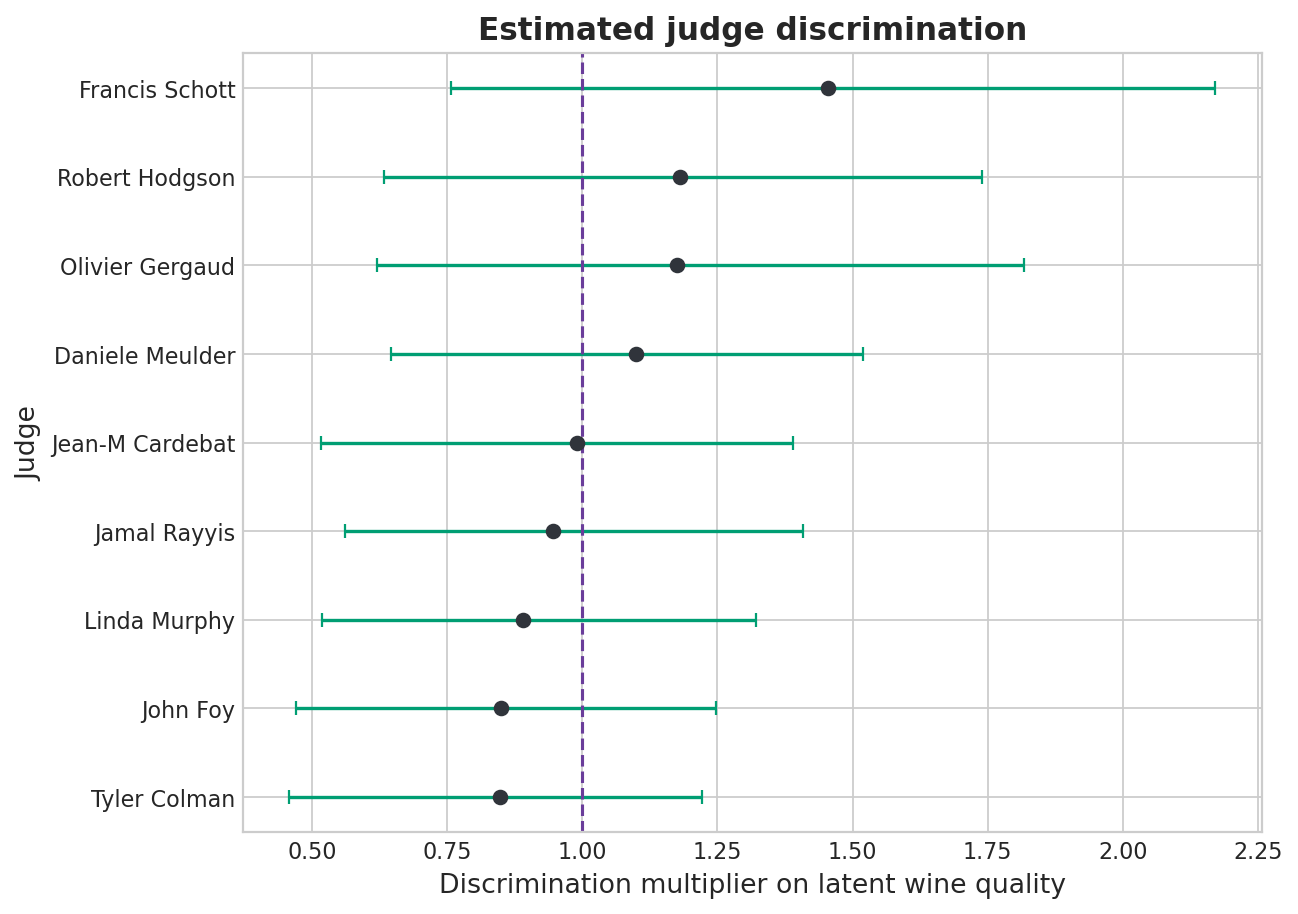

,judge,discrimination_mean,generosity_mean
0,Francis Schott,1.454,0.227
1,Robert Hodgson,1.181,-0.665
2,Olivier Gergaud,1.176,0.143
3,Daniele Meulder,1.099,-0.285
4,Jean-M Cardebat,0.990,-0.557
5,Jamal Rayyis,0.946,0.194
6,Linda Murphy,0.890,0.485
7,John Foy,0.849,0.814
8,Tyler Colman,0.848,-0.356


In [155]:
discrimination_summary = az.summary(
    random_slope_discrimination_idata,
    var_names=["discrimination"],
    hdi_prob=0.94,
)
discrimination_summary = discrimination_summary[["mean", "sd", "hdi_3%", "hdi_97%"]].copy()
discrimination_summary.index = (
    discrimination_summary.index
    .str.replace("discrimination[", "", regex=False)
    .str.replace("]", "", regex=False)
)
discrimination_summary = discrimination_summary.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.6))
discrimination_plot = discrimination_summary.sort_values("mean")
positions = np.arange(len(discrimination_plot))
ax.errorbar(
    discrimination_plot["mean"],
    positions,
    xerr=[
        discrimination_plot["mean"] - discrimination_plot["hdi_3%"],
        discrimination_plot["hdi_97%"] - discrimination_plot["mean"],
    ],
    fmt="o",
    color=COLORS["observed"],
    ecolor=COLORS["posterior"],
    capsize=3,
)
ax.axvline(1.0, color=COLORS["reference"], lw=1.4, ls="--")
ax.set_yticks(positions)
ax.set_yticklabels(discrimination_plot.index)
style_axis(
    ax,
    "Estimated judge discrimination",
    "Discrimination multiplier on latent wine quality",
    "Judge",
)
fig_path = save_figure(fig, "fig_judge_discrimination_posterior.png")
plt.show()

judge_trait_summary = (
    pd.DataFrame(
        {
            "judge": discrimination_summary.index,
            "discrimination_mean": discrimination_summary["mean"].values,
            "generosity_mean": [
                generosity_summary.loc[judge_name, "mean"]
                for judge_name in discrimination_summary.index
            ],
        }
    )
    .sort_values("discrimination_mean", ascending=False)
    .reset_index(drop=True)
)

judge_trait_summary.round(3)


C:\Users\User\AppData\Local\Temp\ipykernel_28960\821864740.py:113: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


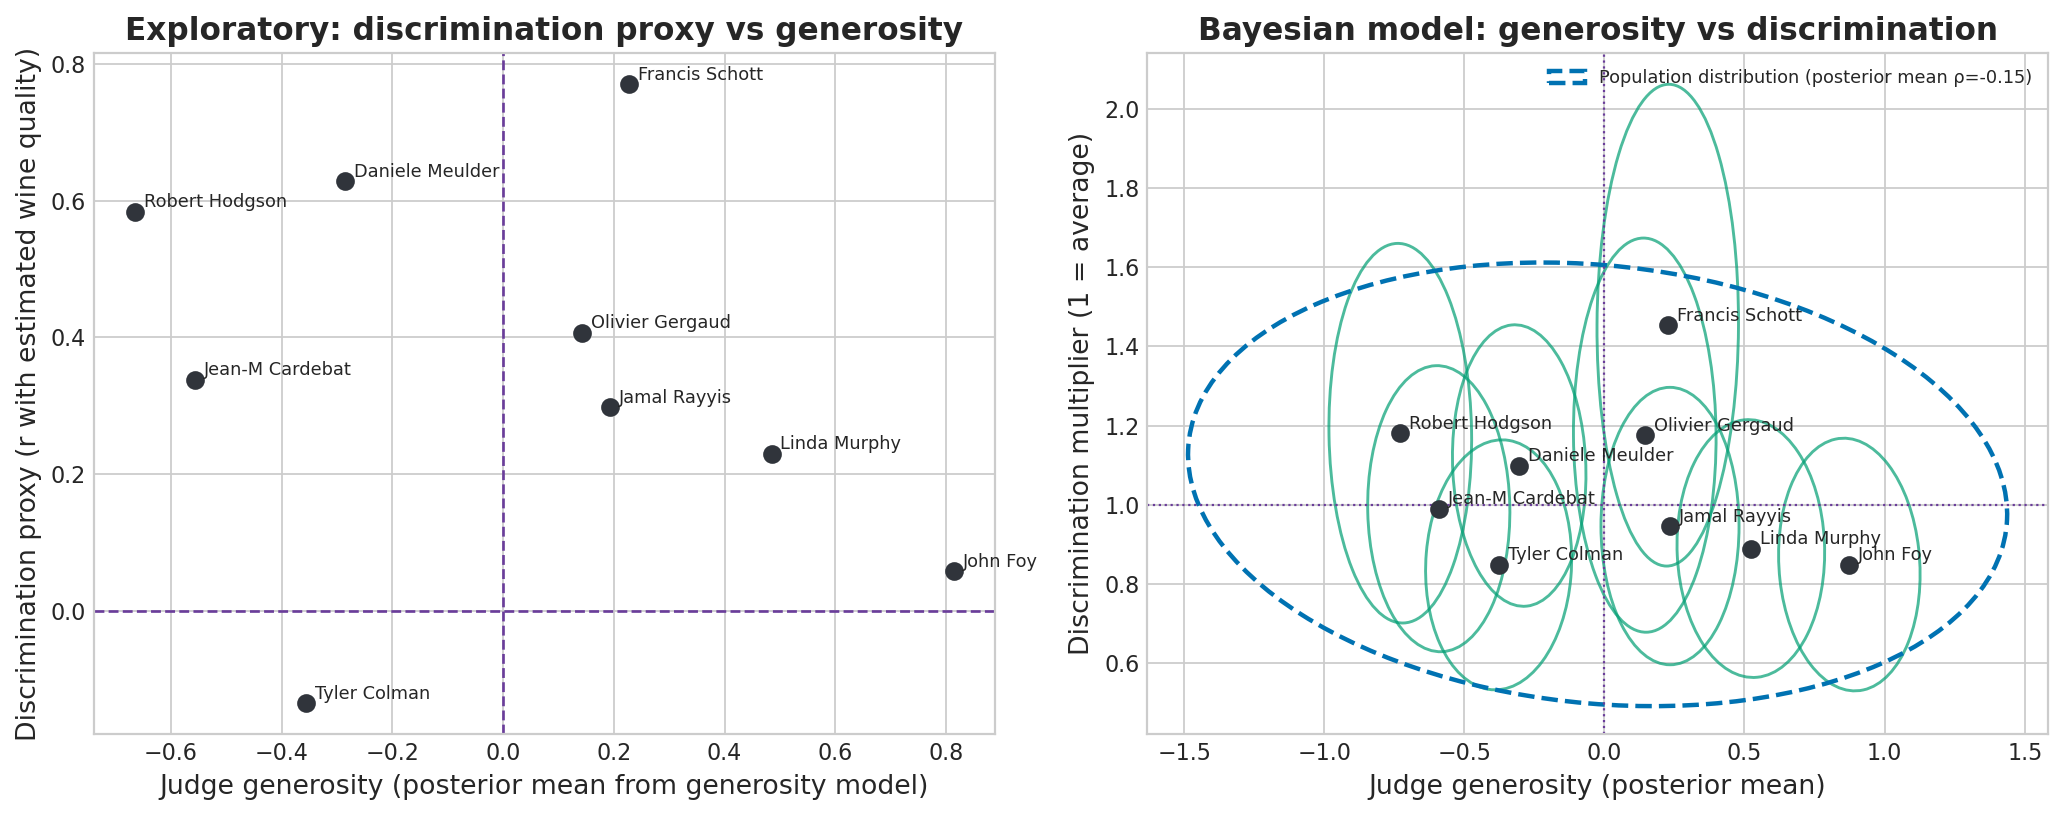

WindowsPath('d:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_judge_generosity_discrimination_ellipse.png')

In [157]:
# Discrimination-vs-generosity: posterior means with uncertainty ellipses.
# Left panel:  exploratory proxy (point estimates only).
# Right panel: Bayesian posterior means + per-judge uncertainty ellipses
#              + population-level ellipse from the fitted joint distribution.
from matplotlib.patches import Ellipse


def draw_cov_ellipse(ax, mean_x, mean_y, cov, n_std=1.5, **kwargs):
    """Draw a covariance ellipse centred at (mean_x, mean_y)."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width = 2 * n_std * np.sqrt(vals[0])
    height = 2 * n_std * np.sqrt(vals[1])
    ellipse = Ellipse(
        xy=(mean_x, mean_y), width=width, height=height, angle=angle, **kwargs
    )
    ax.add_patch(ellipse)


fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# --- Left panel: exploratory proxy (same data as fig_judge_discrimination_proxy) ---
ax_left = axes[0]
ax_left.scatter(gen_vals, disc_vals, color=COLORS["observed"], zorder=3, s=55)
for j in judge_order:
    ax_left.annotate(
        j,
        (judge_gen_proxy[j], judge_discrim_proxy[j]),
        fontsize=8,
        xytext=(4, 2),
        textcoords="offset points",
    )
ax_left.axhline(0, color=COLORS["reference"], lw=1.2, ls="--")
ax_left.axvline(0, color=COLORS["reference"], lw=1.2, ls="--")
style_axis(
    ax_left,
    "Exploratory: discrimination proxy vs generosity",
    "Judge generosity (posterior mean from generosity model)",
    "Discrimination proxy (r with estimated wine quality)",
)

# --- Right panel: Bayesian posterior means + judge-level uncertainty ellipses ---
ax_right = axes[1]

gen_post = random_slope_discrimination_idata.posterior["generosity"]
logd_post = random_slope_discrimination_idata.posterior["log_discrimination"]
d_post = np.exp(logd_post)

for judge_name in judge_order:
    gen_draws = gen_post.sel(judge=judge_name).values.ravel()
    d_draws = d_post.sel(judge=judge_name).values.ravel()
    mean_gen = float(np.mean(gen_draws))
    mean_d = float(np.mean(d_draws))
    cov_j = np.cov(gen_draws, d_draws)
    draw_cov_ellipse(
        ax_right, mean_gen, mean_d, cov_j,
        n_std=1.5,
        facecolor="none",
        edgecolor=COLORS["posterior"],
        alpha=0.7,
        lw=1.3,
    )
    ax_right.scatter(mean_gen, mean_d, color=COLORS["observed"], zorder=3, s=55)
    ax_right.annotate(
        judge_name, (mean_gen, mean_d), fontsize=8,
        xytext=(4, 2), textcoords="offset points",
    )

# Population-level ellipse, transformed from log-discrimination to discrimination.
rho_pop_draws = values_from_dataarray(
    random_slope_discrimination_idata.posterior["rho_generosity_discrimination"]
)
pop_rng = np.random.default_rng(RANDOM_SEED)
pop_draw_count = min(4000, len(rho_pop_draws))
pop_rho_sample = pop_rng.choice(rho_pop_draws, size=pop_draw_count, replace=False)
pop_gen_sample = np.empty(pop_draw_count)
pop_d_sample = np.empty(pop_draw_count)
for draw_idx, rho_value in enumerate(pop_rho_sample):
    pop_cov_log = np.array([
        [sigma_mu_generosity ** 2,
         sigma_mu_generosity * sigma_mu_discrimination * rho_value],
        [sigma_mu_generosity * sigma_mu_discrimination * rho_value,
         sigma_mu_discrimination ** 2],
    ])
    pop_pair = pop_rng.multivariate_normal([0.0, mu_mu_discrimination], pop_cov_log)
    pop_gen_sample[draw_idx] = pop_pair[0]
    pop_d_sample[draw_idx] = np.exp(pop_pair[1])

rho_mean_pop = float(np.mean(rho_pop_draws))
pop_mean = [float(np.mean(pop_gen_sample)), float(np.mean(pop_d_sample))]
pop_cov = np.cov(pop_gen_sample, pop_d_sample)
draw_cov_ellipse(
    ax_right, pop_mean[0], pop_mean[1], pop_cov,
    n_std=1.5,
    facecolor="none",
    edgecolor=COLORS["mean"],
    lw=2.0,
    ls="--",
    label=f"Population distribution (posterior mean ρ={rho_mean_pop:.2f})",
)
ax_right.axhline(1, color=COLORS["reference"], lw=1, ls=":")
ax_right.axvline(0, color=COLORS["reference"], lw=1, ls=":")
ax_right.legend(fontsize=8, loc="upper right")
style_axis(
    ax_right,
    "Bayesian model: generosity vs discrimination",
    "Judge generosity (posterior mean)",
    "Discrimination multiplier (1 = average)",
)

fig.tight_layout()
fig_path = save_figure(fig, "fig_judge_generosity_discrimination_ellipse.png")
plt.show()
fig_path


### Why this is not a standard Wilkinson interaction

A standard Wilkinson interaction between `wine` and `judge` would create judge-specific deviations for individual wines. That answers a different question: judge-specific preference for wine `i`.

Here discrimination means one judge-specific sensitivity to the latent wine-quality scale. The model combines one latent quality value `Q_i` for each wine with one discrimination value `D_j` for each judge through the product `D_j Q_i`.

Because the wine-quality scale is itself inferred inside the model, this custom generative model does not translate cleanly into ordinary Wilkinson notation. Wilkinson notation is very useful for standard mixed models; PyMC is useful here because it lets us write the custom generative model directly.


### Final check

Correlation and repeated measurements are both dependence problems. In Part 1, dependence lives inside a bivariate outcome for each participant: correlation between observed variables. In Part 2, dependence comes from repeated scores by the same judge. The simple wine model separates wine quality from judge generosity and has a clean Wilkinson/Bambi translation. The discrimination model then adds a custom PyMC term for judge-specific sensitivity to latent wine quality. The final correlation parameter asks whether judge generosity and judge log-discrimination are related latent traits.


<a id="section-118"></a>
## 11.8 Model comparison

We fit three models of increasing complexity:

1. **Pooled**: scores vary by wine only; judges ignored — `S_ij = α + Q_i + ε_ij`
2. **Generosity**: wine + judge generosity (random intercepts) — `S_ij = α + Q_i + G_j + ε_ij`
3. **Discrimination**: wine + judge generosity + judge discrimination (random slopes on latent quality) — `μ_ij = G_j + D_j Q_i`

We compare using LOO (leave-one-observation-out cross-validation), the same method from Lecture 10.

LOO measures predictive accuracy: which model best predicts held-out score observations?

Expected findings:
- Generosity model should outperform pooled: judge variation is real and substantial.
- Discrimination model may not outperform generosity substantially: 9 judges provide limited information for estimating latent discrimination.

Higher elpd_loo (or smaller SE-adjusted difference from the best model) indicates better predictive accuracy.

In [ ]:
# Compute log-likelihoods needed for LOO
def ensure_log_likelihood(idata, model):
    if "log_likelihood" not in idata.groups():
        with model:
            pm.compute_log_likelihood(idata)


ensure_log_likelihood(pooled_wine_idata, pooled_wine_model)
ensure_log_likelihood(wine_idata, wine_repeated_model)
ensure_log_likelihood(random_slope_discrimination_idata, random_slope_discrimination_model)

wine_model_comparison = az.compare(
    {
        "pooled": pooled_wine_idata,
        "generosity": wine_idata,
        "discrimination": random_slope_discrimination_idata,
    },
    ic="loo",
)
wine_model_comparison

Output()

Output()

D:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\arviz\stats\stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.68 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
discrimination,0,-238.134049,29.125509,0.000000,1.000000e+00,9.153510,0.000000,True,log
generosity,1,-241.658875,25.889005,3.524826,0.000000e+00,9.146733,1.551796,False,log
pooled,2,-264.888407,18.267894,26.754358,4.652945e-13,8.121601,6.498697,False,log


C:\Users\User\AppData\Local\Temp\ipykernel_24052\2790664280.py:4: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


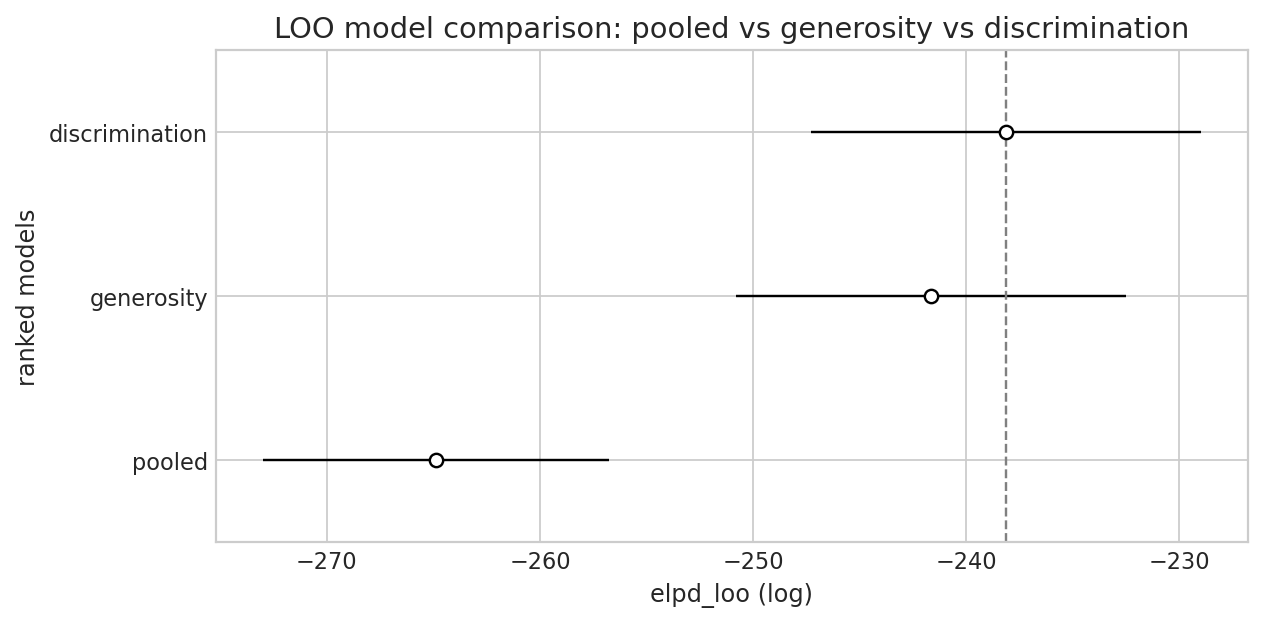

WindowsPath('D:/Repositories/StatisticalComputationAndAnalysis/Lectures/Lecture 11 Correlation and Repeated Measures/figures/fig_wine_model_comparison.png')

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_compare(wine_model_comparison, ax=ax)
ax.set_title("LOO model comparison: pooled vs generosity vs discrimination", fontsize=13)
fig.tight_layout()
fig_path = save_figure(fig, "fig_wine_model_comparison.png")
plt.show()
fig_path